In [1]:
from google.colab import drive
drive.mount('/content/drive/')

import os
%cd /content/drive/MyDrive/ECE232_Project3/

Mounted at /content/drive/
/content/drive/MyDrive/ECE232_Project3


#Question 1

✓ Figures will be saved to: /content/drive/MyDrive/ECE232_Project3/figures
  └─ Saved: Q1_reward_heatmaps.png


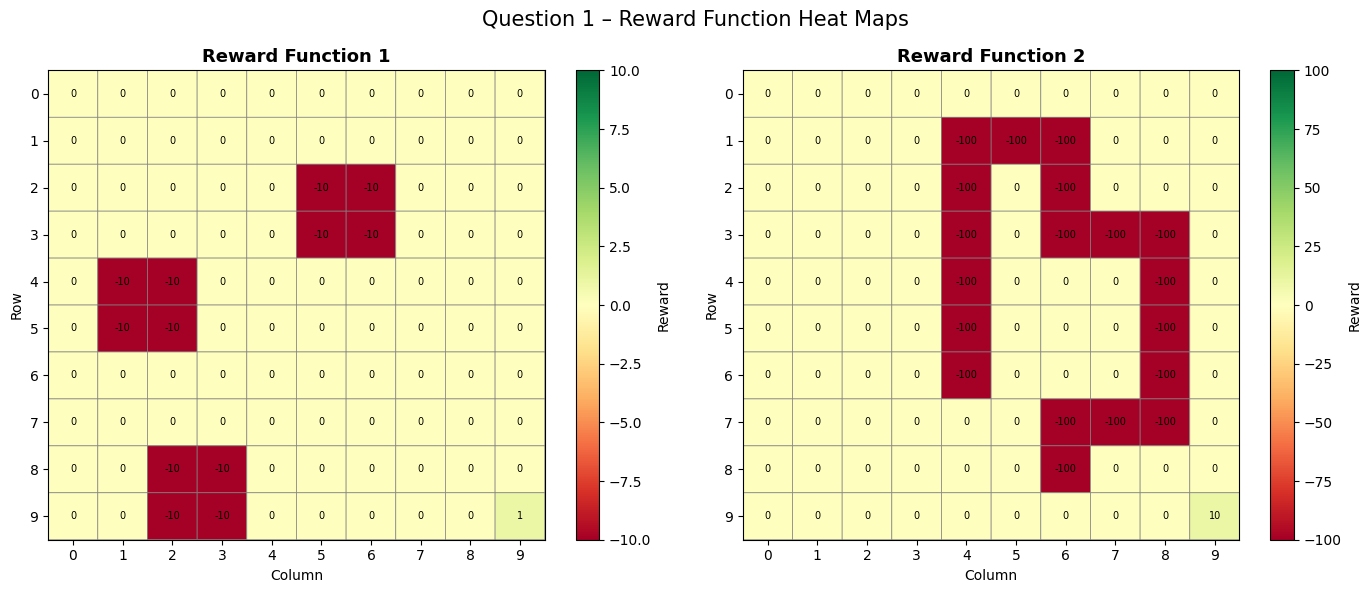

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# ══════════════════════════════════════════════════════════
#  OUTPUT FOLDER (Google Drive)
# ══════════════════════════════════════════════════════════
OUTPUT_DIR = '/content/drive/MyDrive/ECE232_Project3/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Figures will be saved to: {OUTPUT_DIR}")

def savefig(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"  └─ Saved: {filename}")

# ══════════════════════════════════════════════════════════
#  STATE INDEXING: state = col * 10 + row  (column-major)
# ══════════════════════════════════════════════════════════
def build_reward(values: dict, n=100) -> np.ndarray:
    R = np.zeros(n)
    for state, reward in values.items():
        R[state] = reward
    return R

def reward_to_grid(R: np.ndarray) -> np.ndarray:
    """Reshape flat reward vector → 10x10 display grid (Fortran/column-major order)."""
    return R.reshape(10, 10, order='F')

# ══════════════════════════════════════════════════════════
#  REWARD FUNCTION 1  (Figure 6)
#  Penalty: -10  |  Goal (state 99): +1
# ══════════════════════════════════════════════════════════
R1_values = {
    52: -10, 62: -10,   # row 2, cols 5-6
    53: -10, 63: -10,   # row 3, cols 5-6
    14: -10, 24: -10,   # row 4, cols 1-2
    15: -10, 25: -10,   # row 5, cols 1-2
    28: -10, 38: -10,   # row 8, cols 2-3
    29: -10, 39: -10,   # row 9, cols 2-3
    99:   1,            # goal state
}
R1 = build_reward(R1_values)

# ══════════════════════════════════════════════════════════
#  REWARD FUNCTION 2  (Figure 7)
#  Penalty: -100  |  Goal (state 99): +10
# ══════════════════════════════════════════════════════════
R2_values = {
    41: -100, 51: -100, 61: -100,
    42: -100,           62: -100,
    43: -100, 63: -100, 73: -100, 83: -100,
    44: -100,                     84: -100,
    45: -100,                     85: -100,
    46: -100,                     86: -100,
              67: -100, 77: -100, 87: -100,
              68: -100,
    99:  10,
}
R2 = build_reward(R2_values)

# ══════════════════════════════════════════════════════════
#  PLOT HELPER
# ══════════════════════════════════════════════════════════
def plot_reward_heatmap(R: np.ndarray, title: str, ax: plt.Axes):
    grid = reward_to_grid(R)

    vmax = max(abs(R.min()), abs(R.max()))
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    pcm = ax.pcolor(grid, cmap='RdYlGn', norm=norm,
                    edgecolors='grey', linewidths=0.5)
    plt.colorbar(pcm, ax=ax, label='Reward')

    for row in range(10):
        for col in range(10):
            val = grid[row, col]
            ax.text(col + 0.5, row + 0.5, str(int(val)),
                    ha='center', va='center', fontsize=7, color='black')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_xticks(np.arange(10) + 0.5); ax.set_xticklabels(range(10))
    ax.set_yticks(np.arange(10) + 0.5); ax.set_yticklabels(range(10))
    ax.invert_yaxis()

# ══════════════════════════════════════════════════════════
#  QUESTION 1 — Two reward heatmaps
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_reward_heatmap(R1, 'Reward Function 1', axes[0])
plot_reward_heatmap(R2, 'Reward Function 2', axes[1])
plt.suptitle('Question 1 – Reward Function Heat Maps', fontsize=15)
plt.tight_layout()
savefig('Q1_reward_heatmaps.png')
plt.show()

#Question 2

✓ Figures will be saved to: /content/drive/MyDrive/ECE232_Project3/figures
Value iteration converged in N = 21 iterations
  └─ Saved: Q2_optimal_values.png


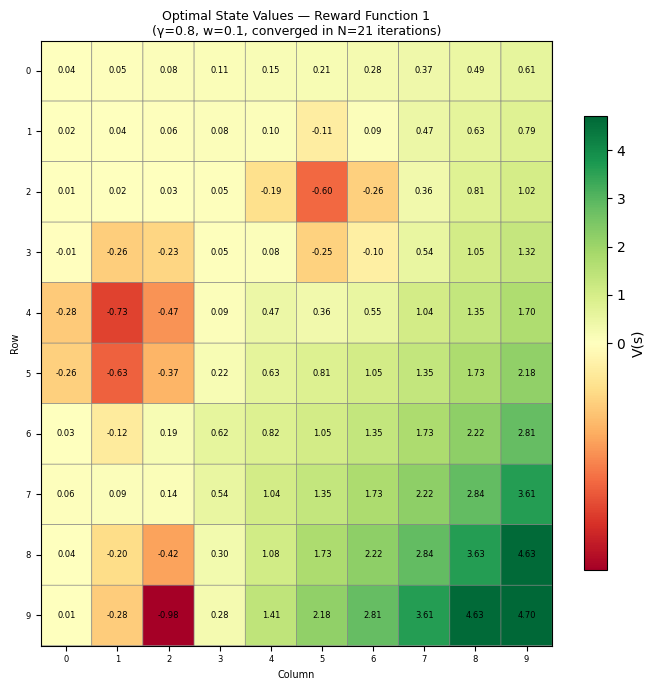


Snapshot steps (1-indexed): [np.int64(1), np.int64(6), np.int64(11), np.int64(16), np.int64(21)]
N = 21
  └─ Saved: Q2_snapshots.png


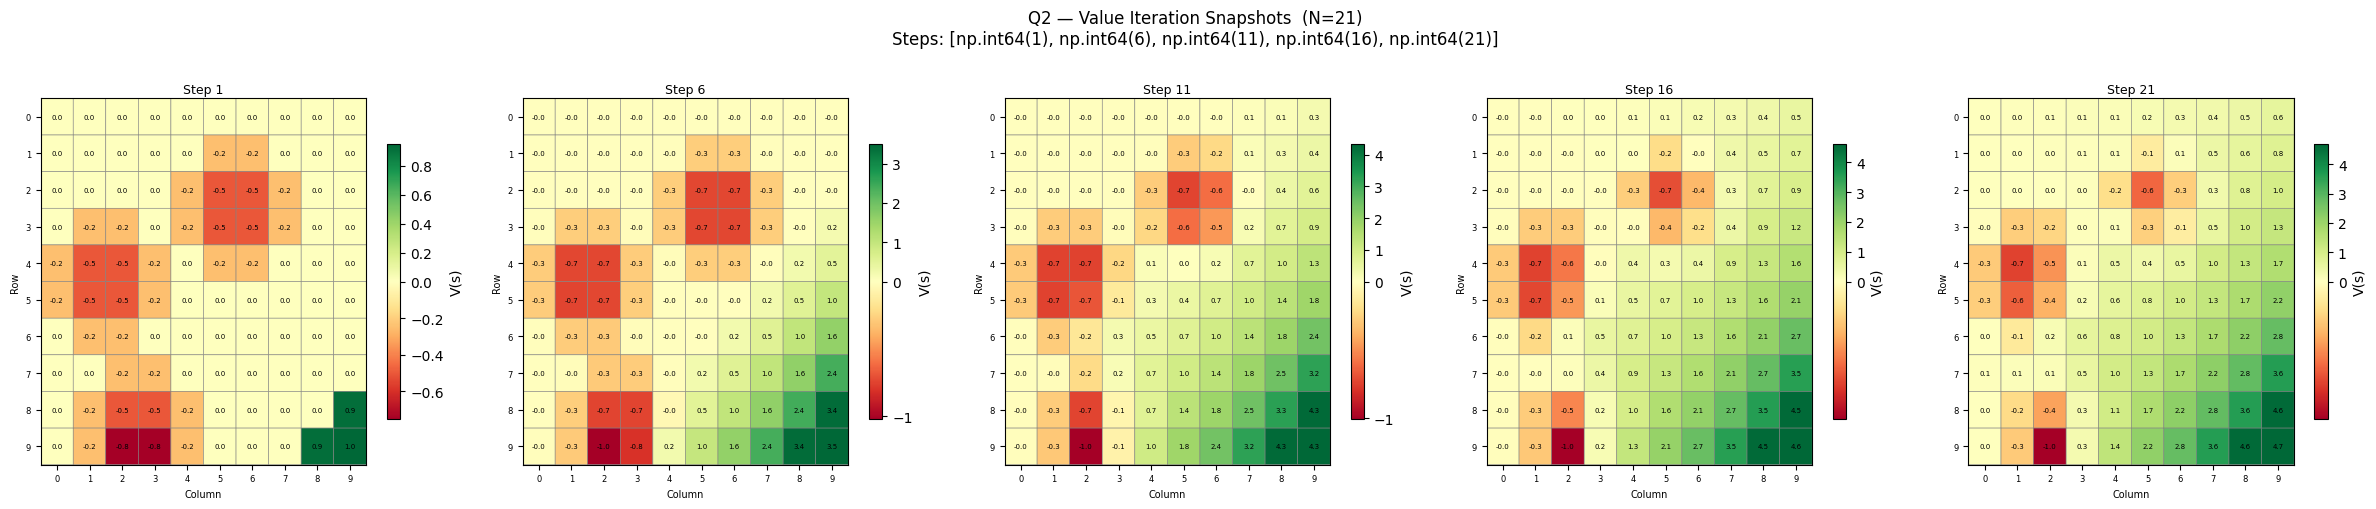

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# ══════════════════════════════════════════════════════════
#  OUTPUT FOLDER (Google Drive)
# ══════════════════════════════════════════════════════════
OUTPUT_DIR = '/content/drive/MyDrive/ECE232_Project3/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Figures will be saved to: {OUTPUT_DIR}")

def savefig(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"  └─ Saved: {filename}")

# ══════════════════════════════════════════════════════════
#  PARAMETERS
# ══════════════════════════════════════════════════════════
N_STATES  = 100
N_ACTIONS = 4          # 0=Right, 1=Left, 2=Up, 3=Down
GRID_SIZE = 10
W         = 0.1        # wind probability
GAMMA     = 0.8        # discount factor
EPSILON   = 0.01       # convergence threshold

# ══════════════════════════════════════════════════════════
#  STATE ↔ GRID HELPERS
#  Numbering (Figure 1): state = col * 10 + row
# ══════════════════════════════════════════════════════════
def state_to_rc(s):
    return s % 10, s // 10

def rc_to_state(row, col):
    return col * 10 + row

def deterministic_move(s, a):
    row, col = state_to_rc(s)
    if   a == 0: col = min(col + 1, GRID_SIZE - 1)
    elif a == 1: col = max(col - 1, 0)
    elif a == 2: row = max(row - 1, 0)
    elif a == 3: row = min(row + 1, GRID_SIZE - 1)
    return rc_to_state(row, col)

# ══════════════════════════════════════════════════════════
#  TRANSITION TENSOR  P[a, s, s']
#  P[a,s,s'] = (1-w)*1{det(s,a)=s'} + (w/4)*Σ_{a'} 1{det(s,a')=s'}
# ══════════════════════════════════════════════════════════
def build_transition(n_states=N_STATES, n_actions=N_ACTIONS, w=W):
    P = np.zeros((n_actions, n_states, n_states))
    for s in range(n_states):
        det = [deterministic_move(s, a) for a in range(n_actions)]
        for a in range(n_actions):
            P[a, s, det[a]] += (1.0 - w)
            for a_wind in range(n_actions):
                P[a, s, det[a_wind]] += w / 4.0
    assert np.allclose(P.sum(axis=2), 1.0), "Transition matrix rows must sum to 1"
    return P

# ══════════════════════════════════════════════════════════
#  REWARD FUNCTION 1  (Figure 6)
#  Penalty: -10  |  Goal (state 99): +1
# ══════════════════════════════════════════════════════════
def build_reward_1(n=N_STATES):
    R = np.zeros(n)
    for s in [52, 62, 53, 63, 14, 24, 15, 25, 28, 38, 29, 39]:
        R[s] = -10.0
    R[99] = 1.0
    return R

# ══════════════════════════════════════════════════════════
#  VALUE ITERATION  (lines 1-13 of pseudocode)
#  Bellman update:  Q[a,s] = Σ_s' P[a,s,s'] * (R[s'] + γ·V[s'])
#                   V_new[s] = max_a Q[a,s]
#  Convergence:     max|V_new - V| < ε
# ══════════════════════════════════════════════════════════
def value_iteration(P, R, gamma=GAMMA, epsilon=EPSILON):
    n_states = P.shape[1]

    # Initialization
    V = np.zeros(n_states)
    history = []

    while True:
        target = R + gamma * V
        Q = P @ target
        V_new = Q.max(axis=0)
        delta = np.abs(V_new - V).max()

        # If the update already satisfies convergence, stop here.
        # Do not count this final convergence-check update as a snapshot step.
        if delta < epsilon:
            V = V_new
            break

        V = V_new
        history.append(V.copy())

    # Final converged value
    return V, history

# ══════════════════════════════════════════════════════════
#  BUILD MDP AND RUN
# ══════════════════════════════════════════════════════════
P      = build_transition()
R1     = build_reward_1()
V_star, history = value_iteration(P, R1)
N = len(history)
print(f"Value iteration converged in N = {N} iterations")

# ══════════════════════════════════════════════════════════
#  PLOTTING HELPERS
# ══════════════════════════════════════════════════════════
def value_to_grid(V):
    return V.reshape(GRID_SIZE, GRID_SIZE, order='F')

def plot_value_grid(V, title, ax, fmt=".2f", fontsize=6):
    grid  = value_to_grid(V)
    vmin, vmax = V.min(), V.max()
    vcenter    = 0.0 if vmin < 0 < vmax else (vmin + vmax) / 2
    norm  = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter,
                                  vmax=max(vmax, vcenter + 1e-9))
    pcm   = ax.pcolor(grid, cmap='RdYlGn', norm=norm,
                      edgecolors='grey', linewidths=0.4)
    plt.colorbar(pcm, ax=ax, shrink=0.75, label='V(s)')
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            ax.text(col + 0.5, row + 0.5, f"{grid[row, col]:{fmt}}",
                    ha='center', va='center', fontsize=fontsize, color='black')
    ax.set_title(title, fontsize=9, pad=4)
    ax.set_xlabel('Column', fontsize=7)
    ax.set_ylabel('Row',    fontsize=7)
    ax.set_xticks(np.arange(GRID_SIZE) + 0.5); ax.set_xticklabels(range(GRID_SIZE), fontsize=6)
    ax.set_yticks(np.arange(GRID_SIZE) + 0.5); ax.set_yticklabels(range(GRID_SIZE), fontsize=6)
    ax.invert_yaxis()

# ══════════════════════════════════════════════════════════
#  QUESTION 2 — PART A: Final optimal value grid
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 7))
plot_value_grid(
    V_star,
    f'Optimal State Values — Reward Function 1\n'
    f'(γ={GAMMA}, w={W}, converged in N={N} iterations)',
    ax
)
plt.tight_layout()
savefig('Q2_optimal_values.png')
plt.show()

# ══════════════════════════════════════════════════════════
#  QUESTION 2 — PART B: 5 snapshots at linearly spaced steps
# ══════════════════════════════════════════════════════════
step_numbers = np.linspace(1, N, 5, dtype=int)   # 1-indexed
step_indices = step_numbers - 1                   # 0-indexed into history[]

print(f"\nSnapshot steps (1-indexed): {list(step_numbers)}")
print(f"N = {N}")

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for ax, idx, step in zip(axes, step_indices, step_numbers):
    plot_value_grid(history[idx], f'Step {step}', ax, fmt=".1f", fontsize=5)

plt.suptitle(
    f'Q2 — Value Iteration Snapshots  (N={N})\n'
    f'Steps: {list(step_numbers)}',
    fontsize=12, y=1.01
)
plt.tight_layout()
savefig('Q2_snapshots.png')
plt.show()

#Question 3

  └─ Saved: Q3_value_heatmap_R1.png


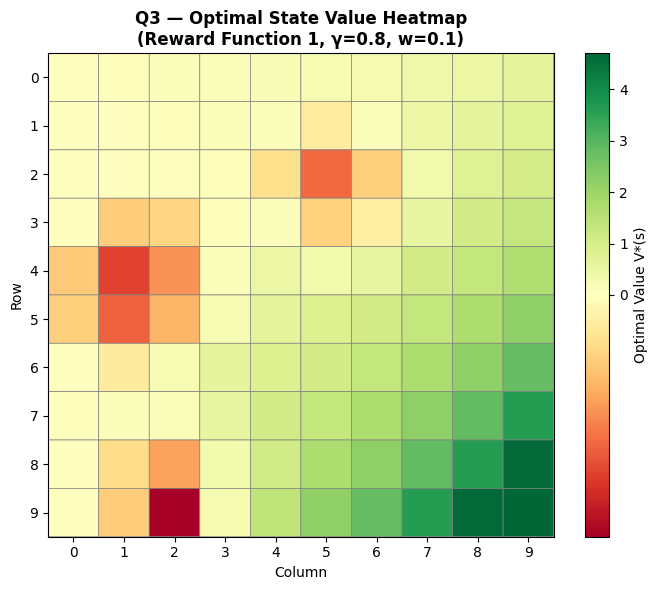

In [4]:
# ══════════════════════════════════════════════════════════
#  QUESTION 3 — Heatmap of optimal state values (Reward 1)
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6))

grid = value_to_grid(V_star)
vmin, vmax = V_star.min(), V_star.max()
vcenter    = 0.0 if vmin < 0 < vmax else (vmin + vmax) / 2
norm       = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter,
                                   vmax=max(vmax, vcenter + 1e-9))

pcm = ax.pcolor(grid, cmap='RdYlGn', norm=norm,
                edgecolors='grey', linewidths=0.5)
plt.colorbar(pcm, ax=ax, label='Optimal Value V*(s)')

ax.set_title('Q3 — Optimal State Value Heatmap\n'
             f'(Reward Function 1, γ={GAMMA}, w={W})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.set_xticks(np.arange(10) + 0.5); ax.set_xticklabels(range(10))
ax.set_yticks(np.arange(10) + 0.5); ax.set_yticklabels(range(10))
ax.invert_yaxis()

plt.tight_layout()
savefig('Q3_value_heatmap_R1.png')
plt.show()

#Question 5

  └─ Saved: Q5_policy_R1.png


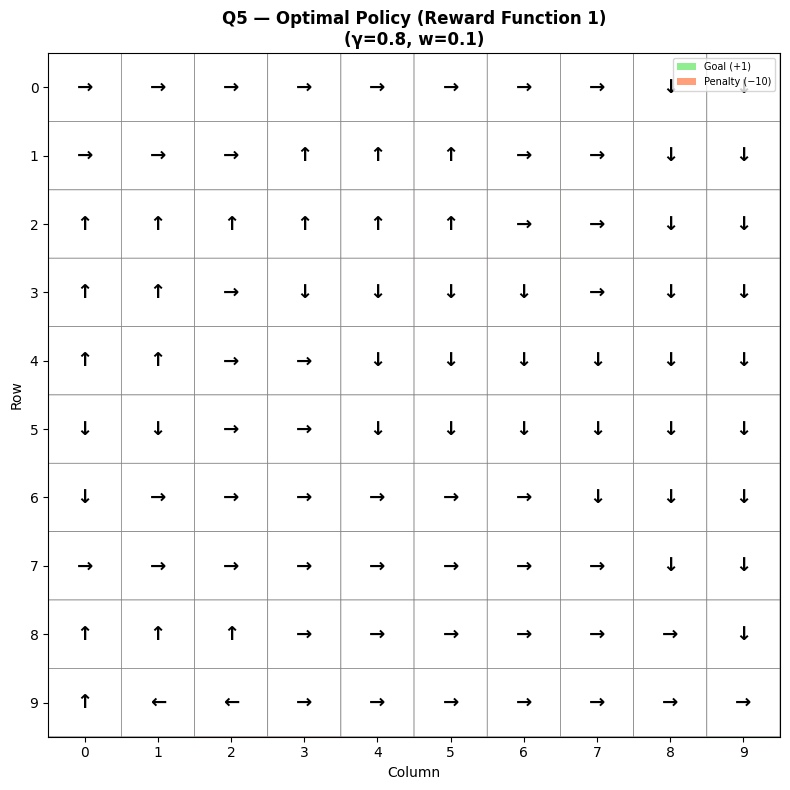


Optimal policy (text view):
→ → → → → → → → ↓ ↓
→ → → ↑ ↑ ↑ → → ↓ ↓
↑ ↑ ↑ ↑ ↑ ↑ → → ↓ ↓
↑ ↑ → ↓ ↓ ↓ ↓ → ↓ ↓
↑ ↑ → → ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ → → ↓ ↓ ↓ ↓ ↓ ↓
↓ → → → → → → ↓ ↓ ↓
→ → → → → → → → ↓ ↓
↑ ↑ ↑ → → → → → → ↓
↑ ← ← → → → → → → →


In [5]:
# ══════════════════════════════════════════════════════════
#  QUESTION 5 — Optimal Policy (Reward Function 1)
#  Implements lines 14-17 of the Value Iteration pseudocode:
#    π(s) = argmax_a  Σ_s' P[a,s,s'] * (R[s'] + γ·V*(s'))
# ══════════════════════════════════════════════════════════

ACTION_ARROWS = {0: '→', 1: '←', 2: '↑', 3: '↓'}

def compute_policy(P, R, V, gamma=GAMMA):
    """
    Computation step (lines 14-17):
    For each state, pick the action that maximises the expected return.

    Returns
    -------
    policy : ndarray (n_states,)  — optimal action index per state
    Q      : ndarray (n_actions, n_states) — action-value matrix
    """
    target = R + gamma * V          # (n_states,)
    Q      = P @ target             # (n_actions, n_states)
    policy = Q.argmax(axis=0)       # (n_states,)
    return policy, Q

def plot_policy_grid(policy, title, ax):
    """
    Display the optimal policy as arrows on a 10×10 grid,
    styled like Figure 1 in the spec.
    """
    grid_policy = policy.reshape(GRID_SIZE, GRID_SIZE, order='F')

    # Light background grid
    ax.pcolor(np.zeros((GRID_SIZE, GRID_SIZE)),
              cmap='Greys', vmin=0, vmax=1,
              edgecolors='grey', linewidths=0.5)

    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            s      = rc_to_state(row, col)
            action = grid_policy[row, col]
            arrow  = ACTION_ARROWS[action]

            # Highlight goal and penalty states
            state_val = R1[s]
            if state_val == 1.0:                          # goal
                ax.add_patch(plt.Rectangle((col, row), 1, 1,
                             color='lightgreen', zorder=0))
            elif state_val == -10.0:                      # penalty
                ax.add_patch(plt.Rectangle((col, row), 1, 1,
                             color='lightsalmon', zorder=0))

            ax.text(col + 0.5, row + 0.5, arrow,
                    ha='center', va='center',
                    fontsize=14, fontweight='bold', color='black', zorder=1)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=6)
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    ax.set_xticks(np.arange(GRID_SIZE) + 0.5); ax.set_xticklabels(range(GRID_SIZE))
    ax.set_yticks(np.arange(GRID_SIZE) + 0.5); ax.set_yticklabels(range(GRID_SIZE))
    ax.set_xlim(0, GRID_SIZE); ax.set_ylim(0, GRID_SIZE)
    ax.invert_yaxis()

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightgreen',  label='Goal (+1)'),
        Patch(facecolor='lightsalmon', label='Penalty (−10)'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              fontsize=7, framealpha=0.8)

# ── Compute and plot ────────────────────────────────────────
policy1, Q1 = compute_policy(P, R1, V_star)

fig, ax = plt.subplots(figsize=(8, 8))
plot_policy_grid(
    policy1,
    f'Q5 — Optimal Policy (Reward Function 1)\n'
    f'(γ={GAMMA}, w={W})',
    ax
)
plt.tight_layout()
savefig('Q5_policy_R1.png')
plt.show()

# ── Print policy as text grid for quick inspection ──────────
print("\nOptimal policy (text view):")
policy_grid = policy1.reshape(GRID_SIZE, GRID_SIZE, order='F')
for row in range(GRID_SIZE):
    print(' '.join(ACTION_ARROWS[policy_grid[row, col]]
                   for col in range(GRID_SIZE)))

#Question 6

Value iteration (R2) converged in N = 31 iterations
  └─ Saved: Q6_optimal_values_R2.png


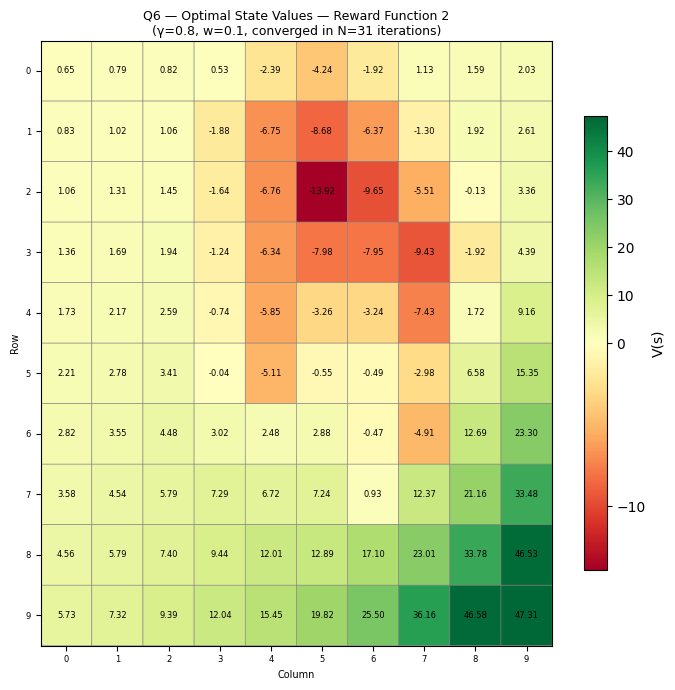

In [6]:
# ══════════════════════════════════════════════════════════
#  QUESTION 6 — Optimal State Values (Reward Function 2)
#  Same value_iteration() from Q2, only reward changes.
# ══════════════════════════════════════════════════════════

def build_reward_2(n=N_STATES):
    """
    Reward Function 2 (Figure 7)
    Penalty: -100  |  Goal (state 99): +10
    """
    R = np.zeros(n)
    for s in [41, 51, 61,           # row 1, cols 4-6
              42,       62,          # row 2, cols 4 & 6
              43, 63, 73, 83,        # row 3, cols 4,6,7,8
              44,             84,    # row 4, cols 4 & 8
              45,             85,    # row 5, cols 4 & 8
              46,             86,    # row 6, cols 4 & 8
                  67, 77, 87,        # row 7, cols 6,7,8
                  68]:               # row 8, col 6
        R[s] = -100.0
    R[99] = 10.0
    return R

# ── Run Value Iteration with Reward Function 2 ─────────────
R2      = build_reward_2()
V2_star, history2 = value_iteration(P, R2)
N2 = len(history2)
print(f"Value iteration (R2) converged in N = {N2} iterations")

# ── Plot: value grid like Figure 1 ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
plot_value_grid(
    V2_star,
    f'Q6 — Optimal State Values — Reward Function 2\n'
    f'(γ={GAMMA}, w={W}, converged in N={N2} iterations)',
    ax
)
plt.tight_layout()
savefig('Q6_optimal_values_R2.png')
plt.show()

#Question 7

  └─ Saved: Q7_value_heatmap_R2.png


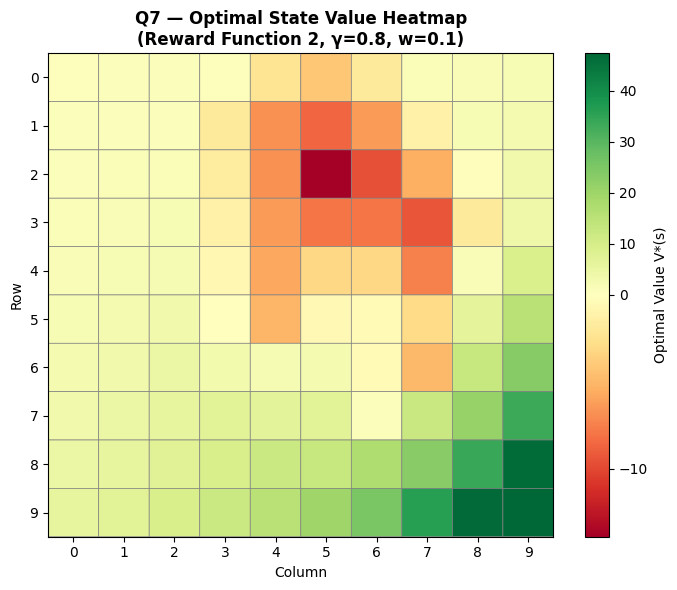

In [8]:
# ══════════════════════════════════════════════════════════
#  QUESTION 7 — Heatmap of optimal state values (Reward 2)
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6))

grid2  = value_to_grid(V2_star)
vmin2, vmax2 = V2_star.min(), V2_star.max()
vcenter2     = 0.0 if vmin2 < 0 < vmax2 else (vmin2 + vmax2) / 2
norm2        = mcolors.TwoSlopeNorm(vmin=vmin2, vcenter=vcenter2,
                                     vmax=max(vmax2, vcenter2 + 1e-9))

pcm = ax.pcolor(grid2, cmap='RdYlGn', norm=norm2,
                edgecolors='grey', linewidths=0.5)
plt.colorbar(pcm, ax=ax, label='Optimal Value V*(s)')

ax.set_title('Q7 — Optimal State Value Heatmap\n'
             f'(Reward Function 2, γ={GAMMA}, w={W})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.set_xticks(np.arange(10) + 0.5); ax.set_xticklabels(range(10))
ax.set_yticks(np.arange(10) + 0.5); ax.set_yticklabels(range(10))
ax.invert_yaxis()

plt.tight_layout()
savefig('Q7_value_heatmap_R2.png')
plt.show()

#Question 8

  └─ Saved: Q8_policy_R2.png


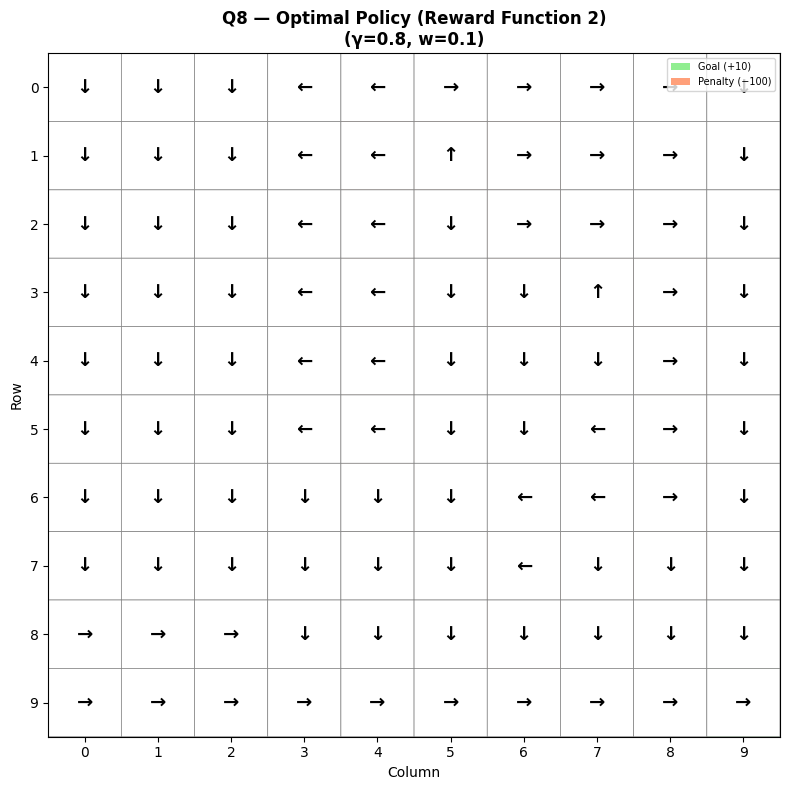


Optimal policy (text view):
↓ ↓ ↓ ← ← → → → → ↓
↓ ↓ ↓ ← ← ↑ → → → ↓
↓ ↓ ↓ ← ← ↓ → → → ↓
↓ ↓ ↓ ← ← ↓ ↓ ↑ → ↓
↓ ↓ ↓ ← ← ↓ ↓ ↓ → ↓
↓ ↓ ↓ ← ← ↓ ↓ ← → ↓
↓ ↓ ↓ ↓ ↓ ↓ ← ← → ↓
↓ ↓ ↓ ↓ ↓ ↓ ← ↓ ↓ ↓
→ → → ↓ ↓ ↓ ↓ ↓ ↓ ↓
→ → → → → → → → → →


In [9]:
# ══════════════════════════════════════════════════════════
#  QUESTION 8 — Optimal Policy (Reward Function 2)
#  Same compute_policy() from Q5, only V* and R change.
# ══════════════════════════════════════════════════════════

def plot_policy_grid_r2(policy, R, title, ax):
    """
    Display optimal policy as arrows on a 10×10 grid.
    Highlights goal (+10) and penalty (−100) states.
    """
    grid_policy = policy.reshape(GRID_SIZE, GRID_SIZE, order='F')

    ax.pcolor(np.zeros((GRID_SIZE, GRID_SIZE)),
              cmap='Greys', vmin=0, vmax=1,
              edgecolors='grey', linewidths=0.5)

    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            s         = rc_to_state(row, col)
            action    = grid_policy[row, col]
            arrow     = ACTION_ARROWS[action]
            state_val = R[s]

            if state_val == 10.0:                         # goal
                ax.add_patch(plt.Rectangle((col, row), 1, 1,
                             color='lightgreen', zorder=0))
            elif state_val == -100.0:                     # penalty
                ax.add_patch(plt.Rectangle((col, row), 1, 1,
                             color='lightsalmon', zorder=0))

            ax.text(col + 0.5, row + 0.5, arrow,
                    ha='center', va='center',
                    fontsize=14, fontweight='bold', color='black', zorder=1)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=6)
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    ax.set_xticks(np.arange(GRID_SIZE) + 0.5); ax.set_xticklabels(range(GRID_SIZE))
    ax.set_yticks(np.arange(GRID_SIZE) + 0.5); ax.set_yticklabels(range(GRID_SIZE))
    ax.set_xlim(0, GRID_SIZE); ax.set_ylim(0, GRID_SIZE)
    ax.invert_yaxis()

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightgreen',  label='Goal (+10)'),
        Patch(facecolor='lightsalmon', label='Penalty (−100)'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              fontsize=7, framealpha=0.8)

# ── Compute and plot ────────────────────────────────────────
policy2, Q2_vals = compute_policy(P, R2, V2_star)

fig, ax = plt.subplots(figsize=(8, 8))
plot_policy_grid_r2(
    policy2, R2,
    f'Q8 — Optimal Policy (Reward Function 2)\n'
    f'(γ={GAMMA}, w={W})',
    ax
)
plt.tight_layout()
savefig('Q8_policy_R2.png')
plt.show()

# ── Print text view ─────────────────────────────────────────
print("\nOptimal policy (text view):")
policy_grid2 = policy2.reshape(GRID_SIZE, GRID_SIZE, order='F')
for row in range(GRID_SIZE):
    print(' '.join(ACTION_ARROWS[policy_grid2[row, col]]
                   for col in range(GRID_SIZE)))

#Question 9

  └─ Saved: Q9_policy_R1_w01_vs_w06.png


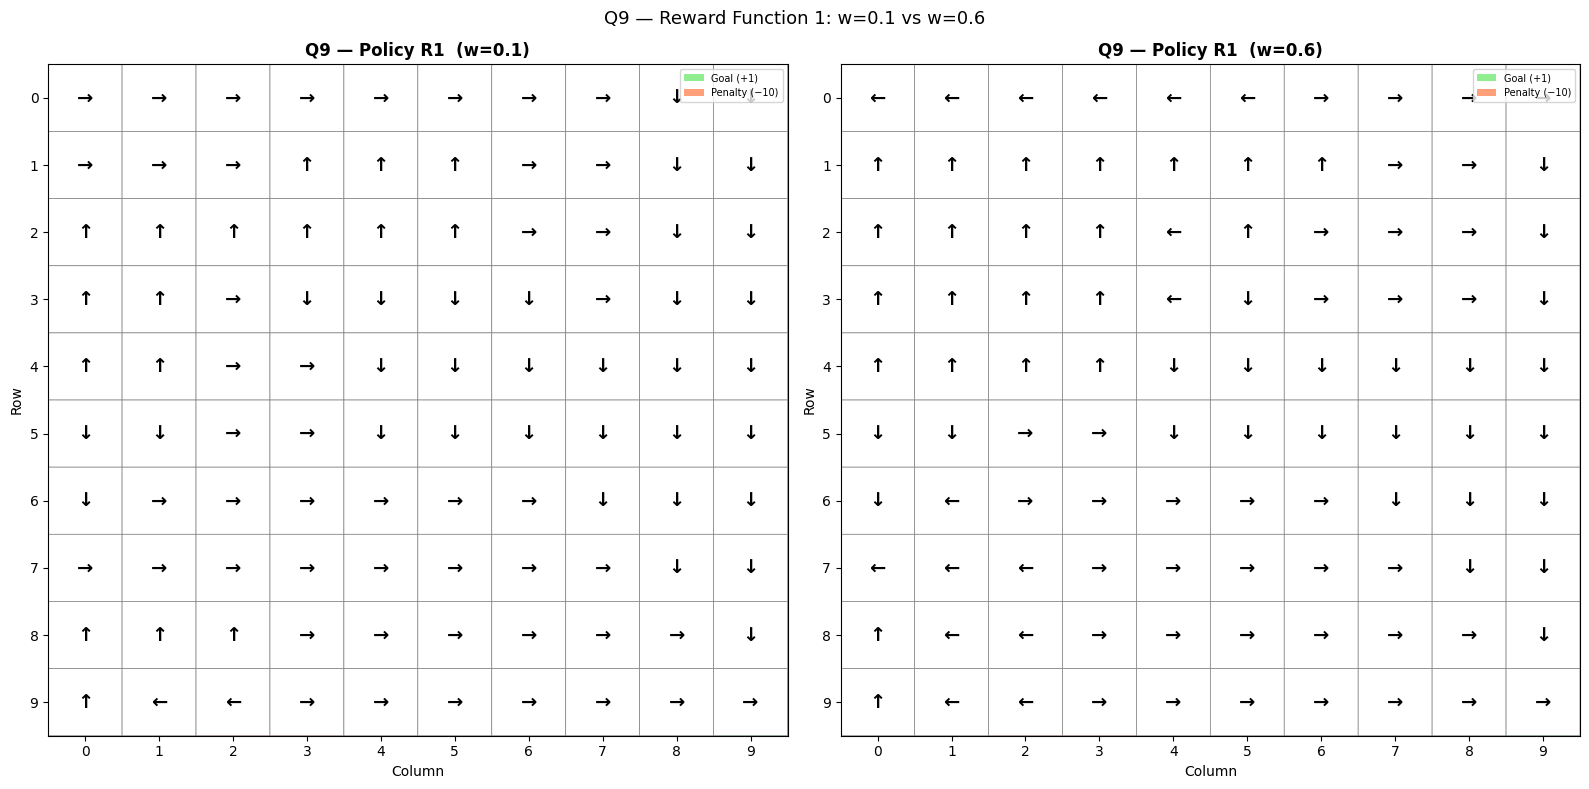

  └─ Saved: Q9_policy_R2_w01_vs_w06.png


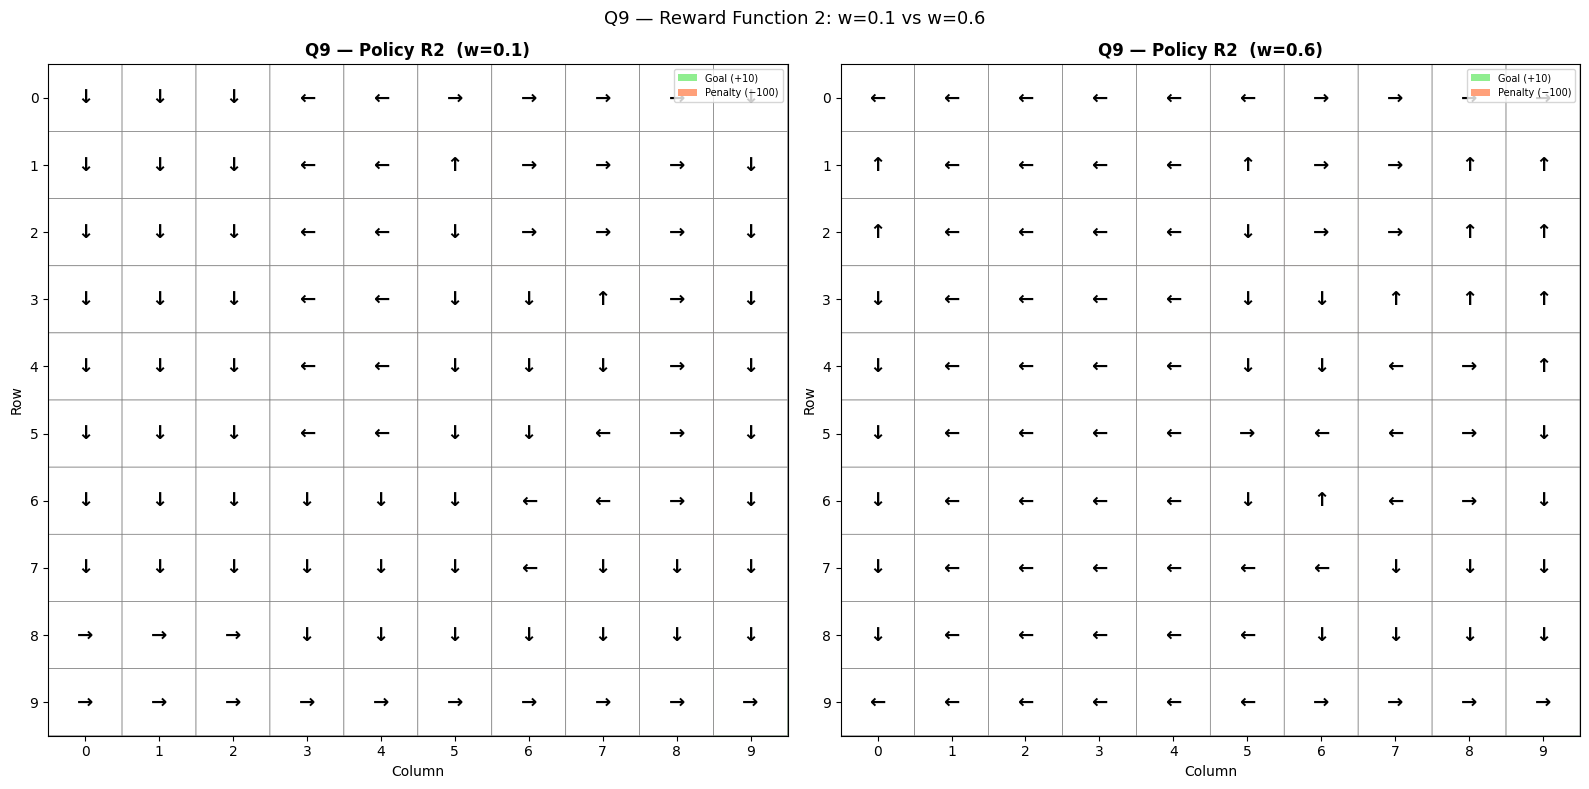

Chosen w for IRL section: 0.1


In [10]:
# ══════════════════════════════════════════════════════════
#  QUESTION 9 — Repeat policy maps with w = 0.6
# ══════════════════════════════════════════════════════════
W_NEW = 0.6

# ── Rebuild transition matrix with new wind probability ─────
P_w06 = build_transition(w=W_NEW)

# ── Value Iteration for both reward functions ───────────────
V1_w06, _ = value_iteration(P_w06, R1)
V2_w06, _ = value_iteration(P_w06, R2)

policy1_w06, _ = compute_policy(P_w06, R1, V1_w06)
policy2_w06, _ = compute_policy(P_w06, R2, V2_w06)

# ── Plot: R1 w=0.1 vs w=0.6 side by side ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_policy_grid(policy1,     f'Q9 — Policy R1  (w={W})',     axes[0])
plot_policy_grid(policy1_w06, f'Q9 — Policy R1  (w={W_NEW})', axes[1])

plt.suptitle('Q9 — Reward Function 1: w=0.1 vs w=0.6', fontsize=13)
plt.tight_layout()
savefig('Q9_policy_R1_w01_vs_w06.png')
plt.show()

# ── Plot: R2 w=0.1 vs w=0.6 side by side ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_policy_grid_r2(policy2,     R2, f'Q9 — Policy R2  (w={W})',     axes[0])
plot_policy_grid_r2(policy2_w06, R2, f'Q9 — Policy R2  (w={W_NEW})', axes[1])

plt.suptitle('Q9 — Reward Function 2: w=0.1 vs w=0.6', fontsize=13)
plt.tight_layout()
savefig('Q9_policy_R2_w01_vs_w06.png')
plt.show()

# ── Choose w for the rest of the project ────────────────────
W_CHOSEN = 0.1
P_CHOSEN = P
print(f"Chosen w for IRL section: {W_CHOSEN}")

#Question 11 & 12

Rmax (R1) = 10.0
Sweeping λ for Reward Function 1 ...


Q11 λ sweep:   0%|          | 0/500 [00:00<?, ?it/s]

  └─ Saved: Q11_accuracy_vs_lambda_R1.png


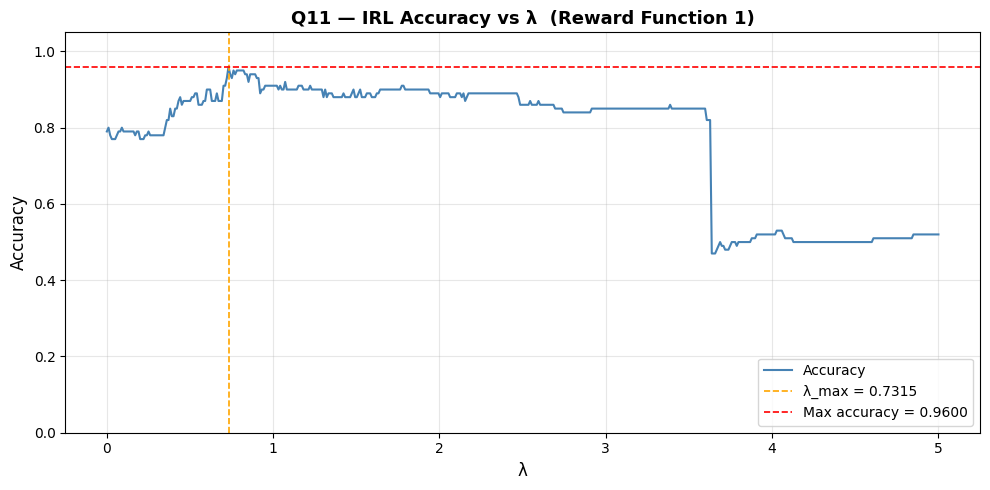


Max accuracy : 0.9600
λ_max(1)     : 0.7315   (Q12 answer)


In [11]:
from cvxopt import matrix, solvers
from tqdm.notebook import tqdm

solvers.options.update({
    'abstol'       : 1e-7,
    'reltol'       : 1e-6,
    'feastol'      : 1e-7,
    'show_progress': False
})

GAMMA_IRL = 0.8   # fixed for IRL section (implementation guide)

# ══════════════════════════════════════════════════════════
#  IRL HELPERS
# ══════════════════════════════════════════════════════════
def build_Pa1(policy, P):
    """Policy transition matrix: Pa1[s, s'] = P[policy[s], s, s']"""
    n   = P.shape[1]
    Pa1 = np.zeros((n, n))
    for s in range(n):
        Pa1[s, :] = P[policy[s], s, :]
    return Pa1

def precompute_irl(policy_expert, P, R_true, gamma=GAMMA_IRL):
    """
    FIXED: mask out rows where action == expert action at that state.
    Otherwise constraint 1 forces ts ≤ 0 for ALL states (via the
    expert action giving Ma[s,:]=0), making the LP trivial.
    """
    n    = P.shape[1]
    Rmax = np.abs(R_true).max()

    Pa1      = build_Pa1(policy_expert, P)
    I_n      = np.eye(n)
    zero_n   = np.zeros((n, n))
    inv_term = np.linalg.inv(I_n - gamma * Pa1)

    G_blocks, h_blocks = [], []

    for a in range(N_ACTIONS):
        Ma   = (Pa1 - P[a]) @ inv_term   # (n, n)

        # ── KEY FIX ──────────────────────────────────────────
        # mask[s]=0 when expert takes action a at state s
        # → that row becomes 0*R + 0*ts ≤ 0  (trivially OK, ts unconstrained)
        # Without this, 0*R + ts ≤ 0 → ts ≤ 0 for ALL states
        mask      = np.array([0.0 if policy_expert[s] == a else 1.0
                               for s in range(n)])
        D         = np.diag(mask)         # diagonal mask matrix
        Ma_masked = D @ Ma                # zero rows where expert takes action a
        I_masked  = D                     # same mask on identity (t part)
        # ─────────────────────────────────────────────────────

        # constraint 1: -Ma_masked*R + I_masked*t ≤ 0
        G_blocks.append(np.hstack([-Ma_masked, I_masked, zero_n]))
        h_blocks.append(np.zeros(n))
        # constraint 2: -Ma_masked*R ≤ 0
        G_blocks.append(np.hstack([-Ma_masked, zero_n,   zero_n]))
        h_blocks.append(np.zeros(n))

    # constraint 3: |R| ≤ u
    G_blocks.append(np.hstack([ I_n, zero_n, -I_n]))
    h_blocks.append(np.zeros(n))
    G_blocks.append(np.hstack([-I_n, zero_n, -I_n]))
    h_blocks.append(np.zeros(n))

    # constraint 4: |R| ≤ Rmax
    G_blocks.append(np.hstack([ I_n, zero_n, zero_n]))
    h_blocks.append(np.full(n, Rmax))
    G_blocks.append(np.hstack([-I_n, zero_n, zero_n]))
    h_blocks.append(np.full(n, Rmax))

    G = np.vstack(G_blocks)
    h = np.concatenate(h_blocks)
    return matrix(G, tc='d'), matrix(h, tc='d'), Rmax

def solve_irl_lp(G_cv, h_cv, lam, n=N_STATES):
    """
    Solve LP for one lambda value.
    Objective: minimize c^T x  where c = [0, -1, +λ]
    (equivalent to maximizing Σ(ti - λui))
    Returns extracted R (length n) or None if infeasible.
    """
    c    = np.concatenate([np.zeros(n), -np.ones(n), lam * np.ones(n)])
    sol  = solvers.lp(matrix(c, tc='d'), G_cv, h_cv)
    if sol['status'] != 'optimal':
        return None
    return np.array(sol['x']).flatten()[:n]

def compute_accuracy(policy_agent, policy_expert):
    """Fraction of states where agent and expert agree."""
    return np.mean(policy_agent == policy_expert)

# ══════════════════════════════════════════════════════════
#  QUESTION 11 — Sweep λ ∈ [0, 5] with 500 values (Reward 1)
#  Expert policy: policy1 from Q5
# ══════════════════════════════════════════════════════════
lambda_values = np.linspace(0, 5, 500)
accuracies_1  = np.zeros(500)

# Precompute G, h once (independent of lambda)
G_cv1, h_cv1, Rmax1 = precompute_irl(policy1, P_CHOSEN, R1)
print(f"Rmax (R1) = {Rmax1}")
print("Sweeping λ for Reward Function 1 ...")

for i, lam in enumerate(tqdm(lambda_values, desc='Q11 λ sweep')):
    R_ext = solve_irl_lp(G_cv1, h_cv1, lam)
    if R_ext is None:
        accuracies_1[i] = 0.0
        continue
    V_ext, _        = value_iteration(P_CHOSEN, R_ext)
    policy_agent, _ = compute_policy(P_CHOSEN, R_ext, V_ext)
    accuracies_1[i] = compute_accuracy(policy_agent, policy1)

# ── Plot λ vs Accuracy ──────────────────────────────────────
best_idx  = accuracies_1.argmax()
lam1_max  = lambda_values[best_idx]
acc1_max  = accuracies_1[best_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lambda_values, accuracies_1, color='steelblue', linewidth=1.5, label='Accuracy')
ax.axvline(lam1_max, color='orange', linestyle='--', linewidth=1.2,
           label=f'λ_max = {lam1_max:.4f}')
ax.axhline(acc1_max, color='red',    linestyle='--', linewidth=1.2,
           label=f'Max accuracy = {acc1_max:.4f}')
ax.set_xlabel('λ',        fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Q11 — IRL Accuracy vs λ  (Reward Function 1)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('Q11_accuracy_vs_lambda_R1.png')
plt.show()

print(f"\nMax accuracy : {acc1_max:.4f}")
print(f"λ_max(1)     : {lam1_max:.4f}   (Q12 answer)")

#Question 13

Extracted reward range: [-10.0000, 10.0000]
  └─ Saved: Q13_reward_heatmaps_R1.png


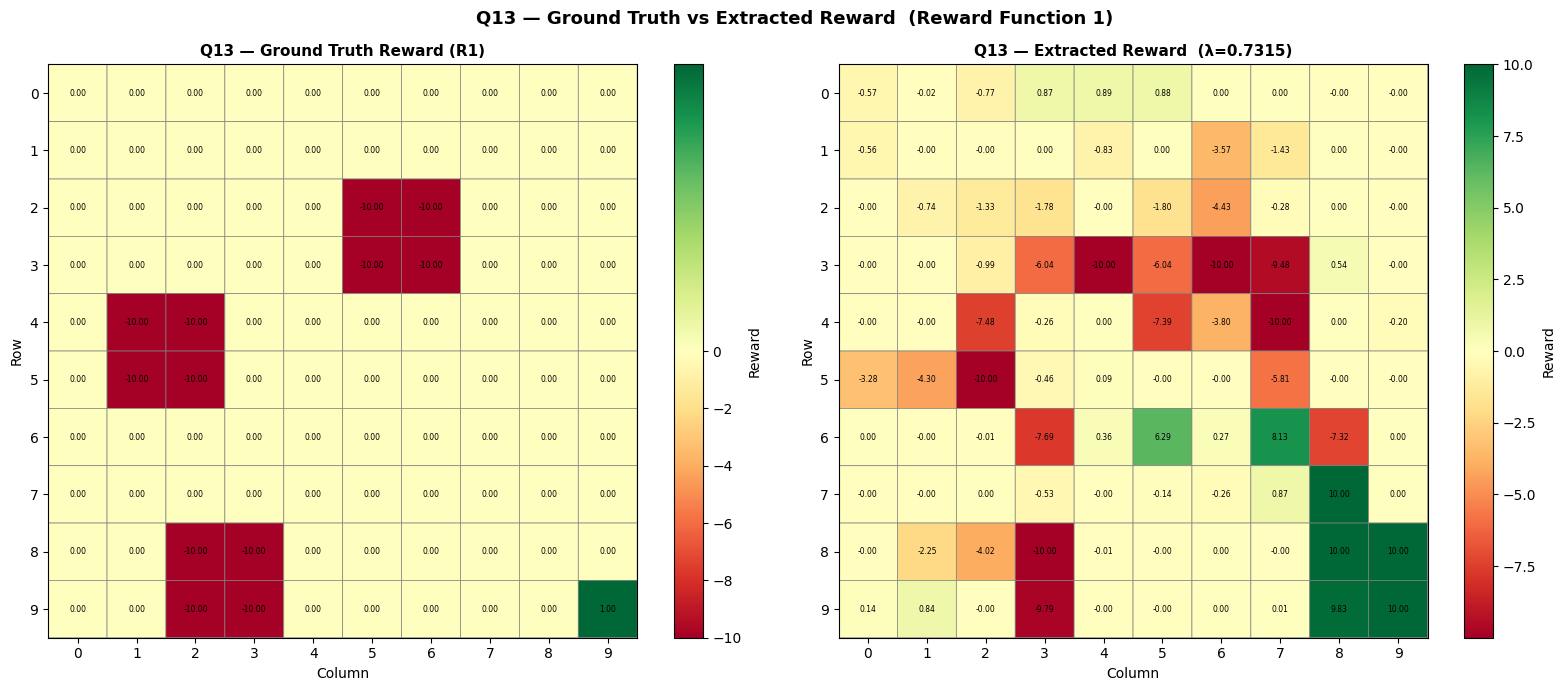

In [12]:
# ══════════════════════════════════════════════════════════
#  QUESTION 13 — Heatmaps: ground truth R1 vs extracted R
#                at λ_max(1)
# ══════════════════════════════════════════════════════════

# ── Extract reward at λ_max(1) ──────────────────────────────
R1_extracted = solve_irl_lp(G_cv1, h_cv1, lam1_max)
print(f"Extracted reward range: [{R1_extracted.min():.4f}, {R1_extracted.max():.4f}]")

# ── Plot helper ─────────────────────────────────────────────
def plot_reward_heatmap_irl(R, title, ax):
    grid = R.reshape(GRID_SIZE, GRID_SIZE, order='F')
    vmin, vmax = R.min(), R.max()
    vcenter    = 0.0 if vmin < 0 < vmax else (vmin + vmax) / 2
    norm       = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter,
                                       vmax=max(vmax, vcenter + 1e-9))
    pcm = ax.pcolor(grid, cmap='RdYlGn', norm=norm,
                    edgecolors='grey', linewidths=0.5)
    plt.colorbar(pcm, ax=ax, label='Reward')
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            ax.text(col + 0.5, row + 0.5, f"{grid[row, col]:.2f}",
                    ha='center', va='center', fontsize=5.5, color='black')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    ax.set_xticks(np.arange(GRID_SIZE) + 0.5); ax.set_xticklabels(range(GRID_SIZE))
    ax.set_yticks(np.arange(GRID_SIZE) + 0.5); ax.set_yticklabels(range(GRID_SIZE))
    ax.invert_yaxis()

# ── Two side-by-side heatmaps ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_reward_heatmap_irl(
    R1,
    f'Q13 — Ground Truth Reward (R1)',
    axes[0]
)
plot_reward_heatmap_irl(
    R1_extracted,
    f'Q13 — Extracted Reward  (λ={lam1_max:.4f})',
    axes[1]
)

plt.suptitle('Q13 — Ground Truth vs Extracted Reward  (Reward Function 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('Q13_reward_heatmaps_R1.png')
plt.show()

#Question 14

  └─ Saved: Q14_value_heatmap_extracted_R1.png


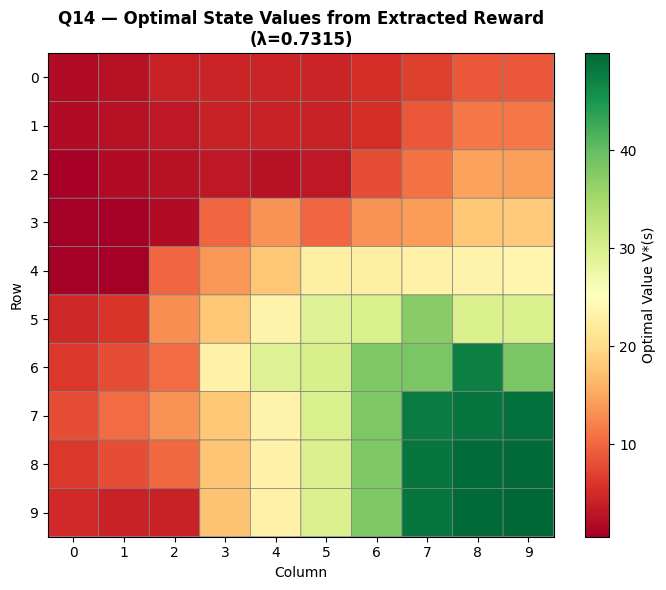

In [13]:
# ══════════════════════════════════════════════════════════
#  QUESTION 14 — Optimal values from extracted reward
#                (same value_iteration() as Q2)
# ══════════════════════════════════════════════════════════
V1_extracted, _ = value_iteration(P_CHOSEN, R1_extracted)

fig, ax = plt.subplots(figsize=(7, 6))

grid_ext   = value_to_grid(V1_extracted)
vmin, vmax = V1_extracted.min(), V1_extracted.max()
vcenter    = 0.0 if vmin < 0 < vmax else (vmin + vmax) / 2
norm       = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter,
                                   vmax=max(vmax, vcenter + 1e-9))

pcm = ax.pcolor(grid_ext, cmap='RdYlGn', norm=norm,
                edgecolors='grey', linewidths=0.5)
plt.colorbar(pcm, ax=ax, label='Optimal Value V*(s)')

ax.set_title(f'Q14 — Optimal State Values from Extracted Reward\n'
             f'(λ={lam1_max:.4f})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.set_xticks(np.arange(GRID_SIZE) + 0.5); ax.set_xticklabels(range(GRID_SIZE))
ax.set_yticks(np.arange(GRID_SIZE) + 0.5); ax.set_yticklabels(range(GRID_SIZE))
ax.invert_yaxis()

plt.tight_layout()
savefig('Q14_value_heatmap_extracted_R1.png')
plt.show()

#Question 16

  └─ Saved: Q16_policy_extracted_R1.png


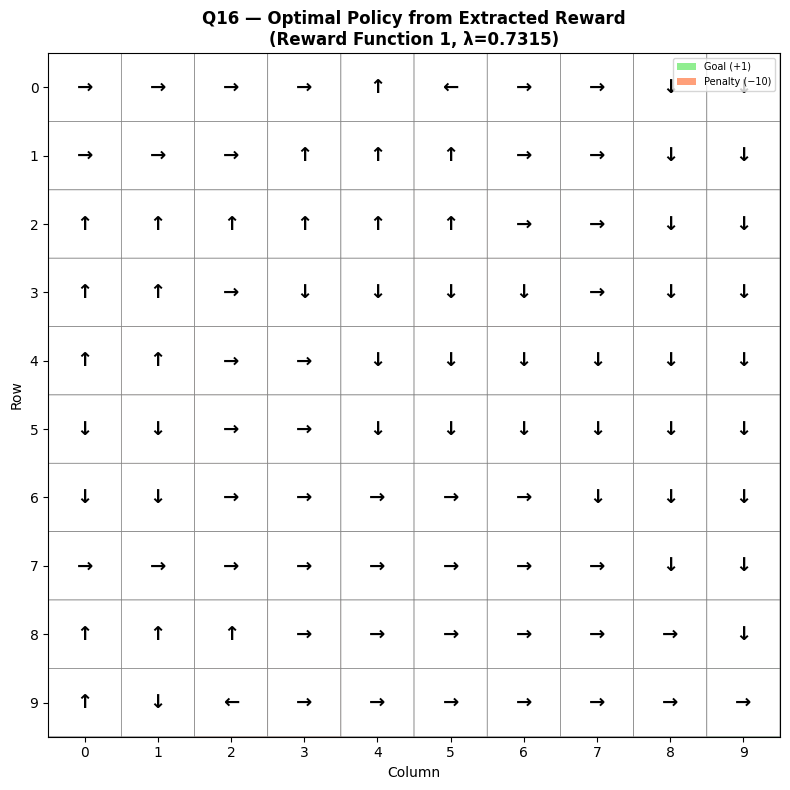


Extracted policy (text view):
→ → → → ↑ ← → → ↓ ↓
→ → → ↑ ↑ ↑ → → ↓ ↓
↑ ↑ ↑ ↑ ↑ ↑ → → ↓ ↓
↑ ↑ → ↓ ↓ ↓ ↓ → ↓ ↓
↑ ↑ → → ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ → → ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ → → → → → ↓ ↓ ↓
→ → → → → → → → ↓ ↓
↑ ↑ ↑ → → → → → → ↓
↑ ↓ ← → → → → → → →


In [14]:
# ══════════════════════════════════════════════════════════
#  QUESTION 16 — Optimal policy from extracted reward
#                (same compute_policy() as Q5)
# ══════════════════════════════════════════════════════════
policy1_extracted, _ = compute_policy(P_CHOSEN, R1_extracted, V1_extracted)

fig, ax = plt.subplots(figsize=(8, 8))
plot_policy_grid(
    policy1_extracted,
    f'Q16 — Optimal Policy from Extracted Reward\n'
    f'(Reward Function 1, λ={lam1_max:.4f})',
    ax
)
plt.tight_layout()
savefig('Q16_policy_extracted_R1.png')
plt.show()

# ── Text view for quick inspection ─────────────────────────
print("\nExtracted policy (text view):")
pg = policy1_extracted.reshape(GRID_SIZE, GRID_SIZE, order='F')
for row in range(GRID_SIZE):
    print(' '.join(ACTION_ARROWS[pg[row, col]] for col in range(GRID_SIZE)))

#Question 18

Rmax (R2) = 100.0
Sweeping λ for Reward Function 2 ...


Q18 λ sweep:   0%|          | 0/500 [00:00<?, ?it/s]

  └─ Saved: Q18_accuracy_vs_lambda_R2.png


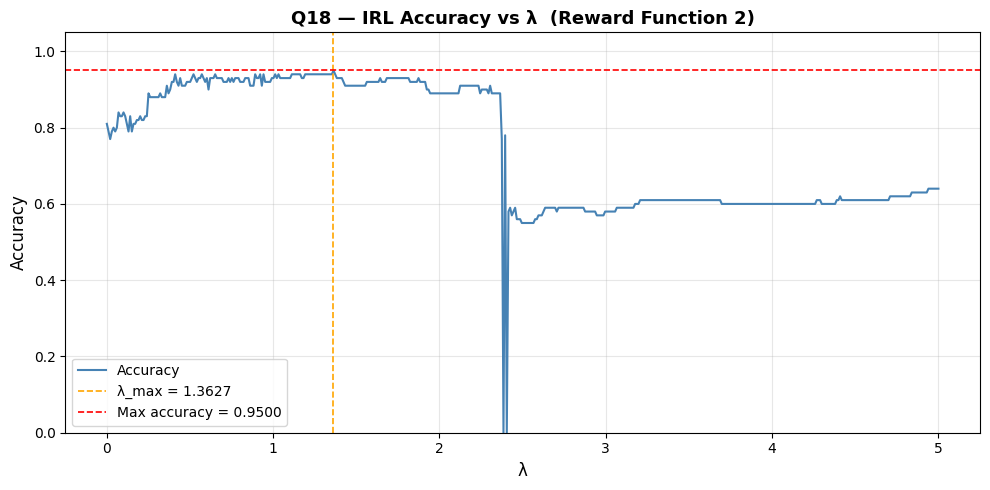


Max accuracy : 0.9500
λ_max(2)     : 1.3627   (Q19 answer)


In [15]:
# ══════════════════════════════════════════════════════════
#  QUESTION 18 — Sweep λ ∈ [0, 5] with 500 values (Reward 2)
#  Expert policy: policy2 from Q8
# ══════════════════════════════════════════════════════════

# Precompute G, h once for R2 expert policy
G_cv2, h_cv2, Rmax2 = precompute_irl(policy2, P_CHOSEN, R2)
print(f"Rmax (R2) = {Rmax2}")
print("Sweeping λ for Reward Function 2 ...")

accuracies_2 = np.zeros(500)

for i, lam in enumerate(tqdm(lambda_values, desc='Q18 λ sweep')):
    R_ext = solve_irl_lp(G_cv2, h_cv2, lam)
    if R_ext is None:
        accuracies_2[i] = 0.0
        continue
    V_ext, _        = value_iteration(P_CHOSEN, R_ext)
    policy_agent, _ = compute_policy(P_CHOSEN, R_ext, V_ext)
    accuracies_2[i] = compute_accuracy(policy_agent, policy2)

# ── Plot λ vs Accuracy ──────────────────────────────────────
best_idx2 = accuracies_2.argmax()
lam2_max  = lambda_values[best_idx2]
acc2_max  = accuracies_2[best_idx2]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lambda_values, accuracies_2, color='steelblue', linewidth=1.5, label='Accuracy')
ax.axvline(lam2_max, color='orange', linestyle='--', linewidth=1.2,
           label=f'λ_max = {lam2_max:.4f}')
ax.axhline(acc2_max, color='red',    linestyle='--', linewidth=1.2,
           label=f'Max accuracy = {acc2_max:.4f}')
ax.set_xlabel('λ',        fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Q18 — IRL Accuracy vs λ  (Reward Function 2)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('Q18_accuracy_vs_lambda_R2.png')
plt.show()

print(f"\nMax accuracy : {acc2_max:.4f}")
print(f"λ_max(2)     : {lam2_max:.4f}   (Q19 answer)")

#Question 20

Extracted reward range: [-100.0000, 100.0000]
  └─ Saved: Q20_reward_heatmaps_R2.png


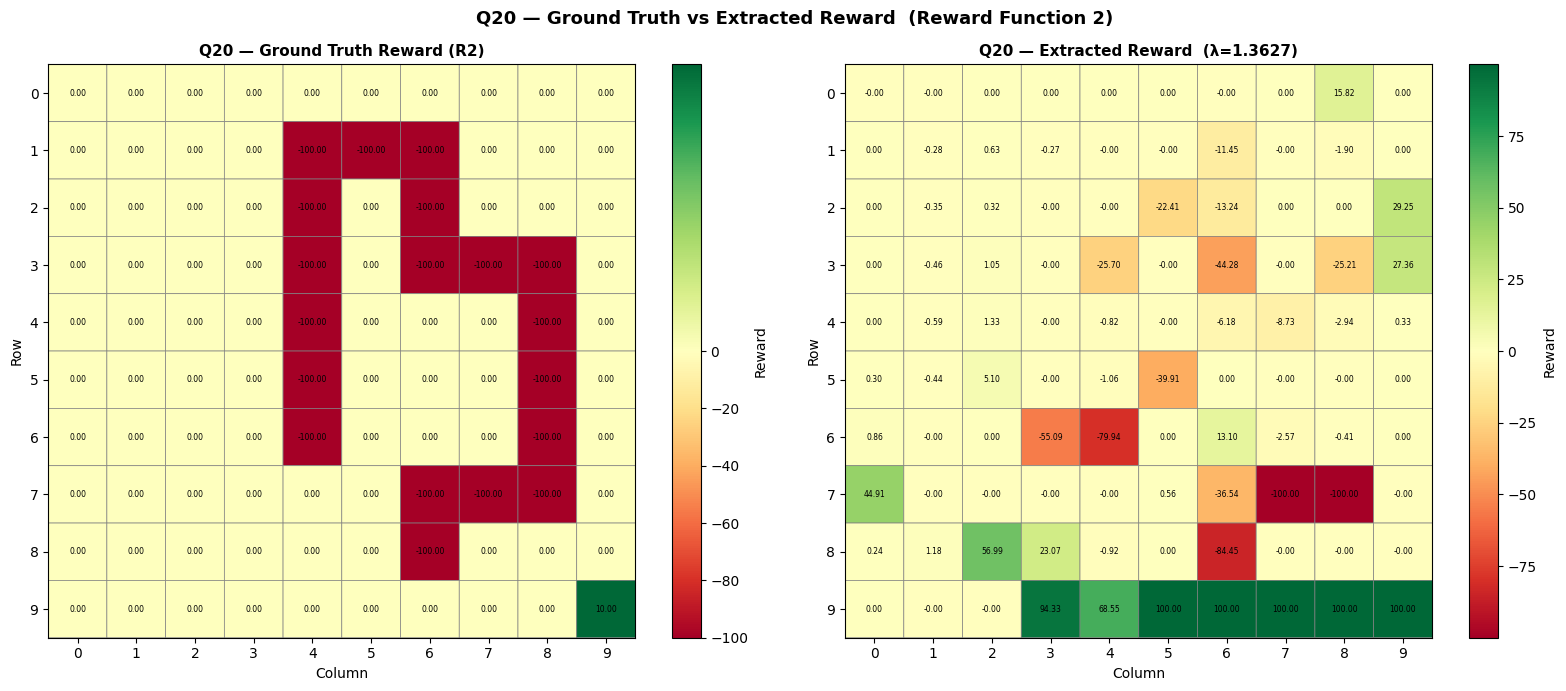

In [16]:
# ══════════════════════════════════════════════════════════
#  QUESTION 20 — Heatmaps: ground truth R2 vs extracted R
#                at λ_max(2)
# ══════════════════════════════════════════════════════════

# ── Extract reward at λ_max(2) ──────────────────────────────
R2_extracted = solve_irl_lp(G_cv2, h_cv2, lam2_max)
print(f"Extracted reward range: [{R2_extracted.min():.4f}, {R2_extracted.max():.4f}]")

# ── Two side-by-side heatmaps ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_reward_heatmap_irl(
    R2,
    'Q20 — Ground Truth Reward (R2)',
    axes[0]
)
plot_reward_heatmap_irl(
    R2_extracted,
    f'Q20 — Extracted Reward  (λ={lam2_max:.4f})',
    axes[1]
)

plt.suptitle('Q20 — Ground Truth vs Extracted Reward  (Reward Function 2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('Q20_reward_heatmaps_R2.png')
plt.show()

#Question 21

  └─ Saved: Q21_value_heatmap_extracted_R2.png


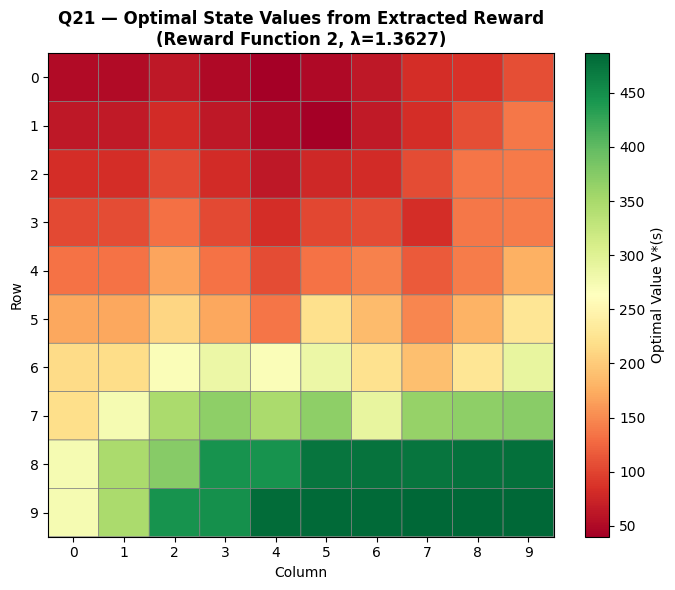

In [17]:
# ══════════════════════════════════════════════════════════
#  QUESTION 21 — Optimal values from extracted reward (R2)
#                (same value_iteration() as Q2)
# ══════════════════════════════════════════════════════════
V2_extracted, _ = value_iteration(P_CHOSEN, R2_extracted)

fig, ax = plt.subplots(figsize=(7, 6))

grid_ext2  = value_to_grid(V2_extracted)
vmin, vmax = V2_extracted.min(), V2_extracted.max()
vcenter    = 0.0 if vmin < 0 < vmax else (vmin + vmax) / 2
norm       = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter,
                                   vmax=max(vmax, vcenter + 1e-9))

pcm = ax.pcolor(grid_ext2, cmap='RdYlGn', norm=norm,
                edgecolors='grey', linewidths=0.5)
plt.colorbar(pcm, ax=ax, label='Optimal Value V*(s)')

ax.set_title(f'Q21 — Optimal State Values from Extracted Reward\n'
             f'(Reward Function 2, λ={lam2_max:.4f})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.set_xticks(np.arange(GRID_SIZE) + 0.5); ax.set_xticklabels(range(GRID_SIZE))
ax.set_yticks(np.arange(GRID_SIZE) + 0.5); ax.set_yticklabels(range(GRID_SIZE))
ax.invert_yaxis()

plt.tight_layout()
savefig('Q21_value_heatmap_extracted_R2.png')
plt.show()

#Question 23

  └─ Saved: Q23_policy_extracted_R2.png


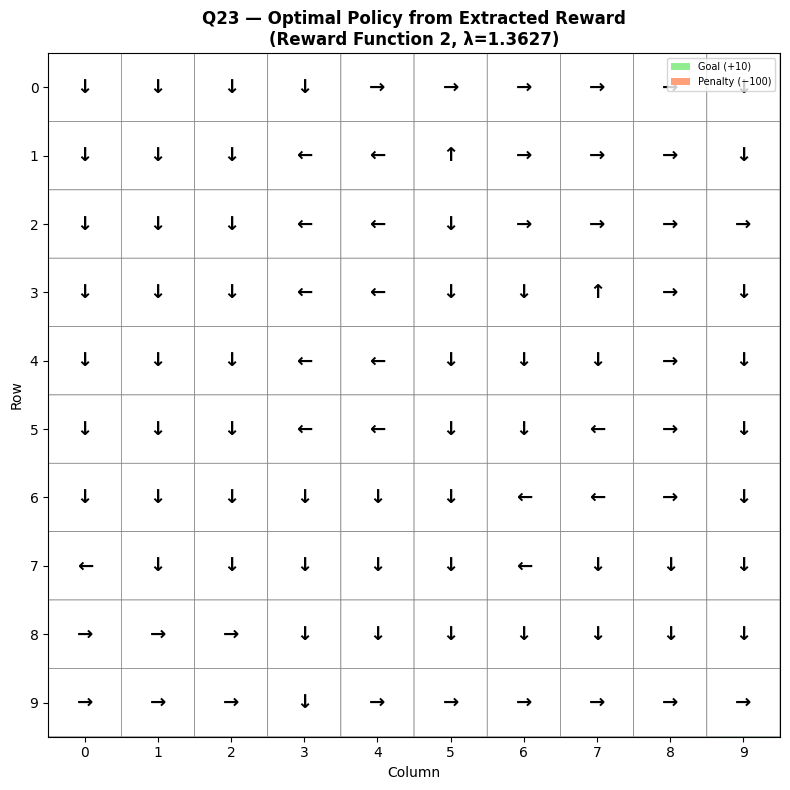


Extracted policy (text view):
↓ ↓ ↓ ↓ → → → → → ↓
↓ ↓ ↓ ← ← ↑ → → → ↓
↓ ↓ ↓ ← ← ↓ → → → →
↓ ↓ ↓ ← ← ↓ ↓ ↑ → ↓
↓ ↓ ↓ ← ← ↓ ↓ ↓ → ↓
↓ ↓ ↓ ← ← ↓ ↓ ← → ↓
↓ ↓ ↓ ↓ ↓ ↓ ← ← → ↓
← ↓ ↓ ↓ ↓ ↓ ← ↓ ↓ ↓
→ → → ↓ ↓ ↓ ↓ ↓ ↓ ↓
→ → → ↓ → → → → → →

Policy match accuracy (vs Q8): 0.9500  (95 / 100 states agree)


In [18]:
# ══════════════════════════════════════════════════════════
#  QUESTION 23 — Optimal policy from extracted reward (R2)
#                (same compute_policy() as Q5/Q8)
# ══════════════════════════════════════════════════════════
policy2_extracted, _ = compute_policy(P_CHOSEN, R2_extracted, V2_extracted)

fig, ax = plt.subplots(figsize=(8, 8))
plot_policy_grid_r2(
    policy2_extracted,
    R2,
    f'Q23 — Optimal Policy from Extracted Reward\n'
    f'(Reward Function 2, λ={lam2_max:.4f})',
    ax
)
plt.tight_layout()
savefig('Q23_policy_extracted_R2.png')
plt.show()

# ── Text view for quick inspection ─────────────────────────
print("\nExtracted policy (text view):")
pg2 = policy2_extracted.reshape(GRID_SIZE, GRID_SIZE, order='F')
for row in range(GRID_SIZE):
    print(' '.join(ACTION_ARROWS[pg2[row, col]] for col in range(GRID_SIZE)))

# ── Accuracy vs Q8 expert policy ───────────────────────────
acc_q23 = compute_accuracy(policy2_extracted, policy2)
print(f"\nPolicy match accuracy (vs Q8): {acc_q23:.4f}  ({int(acc_q23*100)} / 100 states agree)")

#Question 25

  └─ Saved: Q25_discrepancy_marked.png


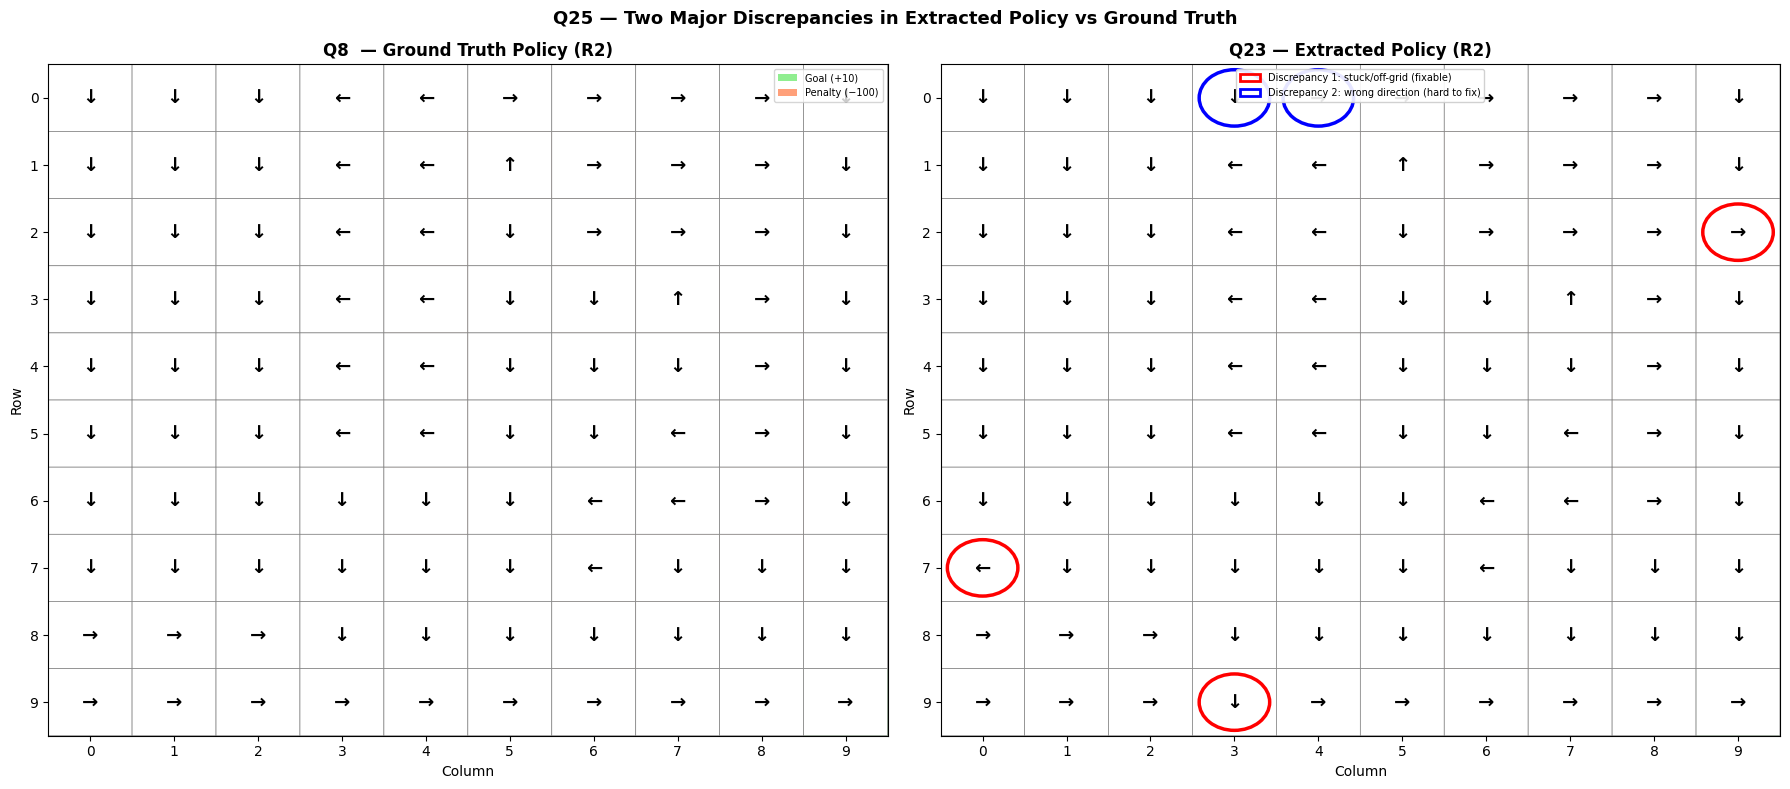

Re-sweeping λ with absorbing goal fix ...


Q25 λ sweep (fixed):   0%|          | 0/500 [00:00<?, ?it/s]

Before fix — max accuracy: 0.9500  at λ=1.3627
After  fix — max accuracy: 0.9900  at λ=0.5511
  └─ Saved: Q25_accuracy_before_after_fix.png


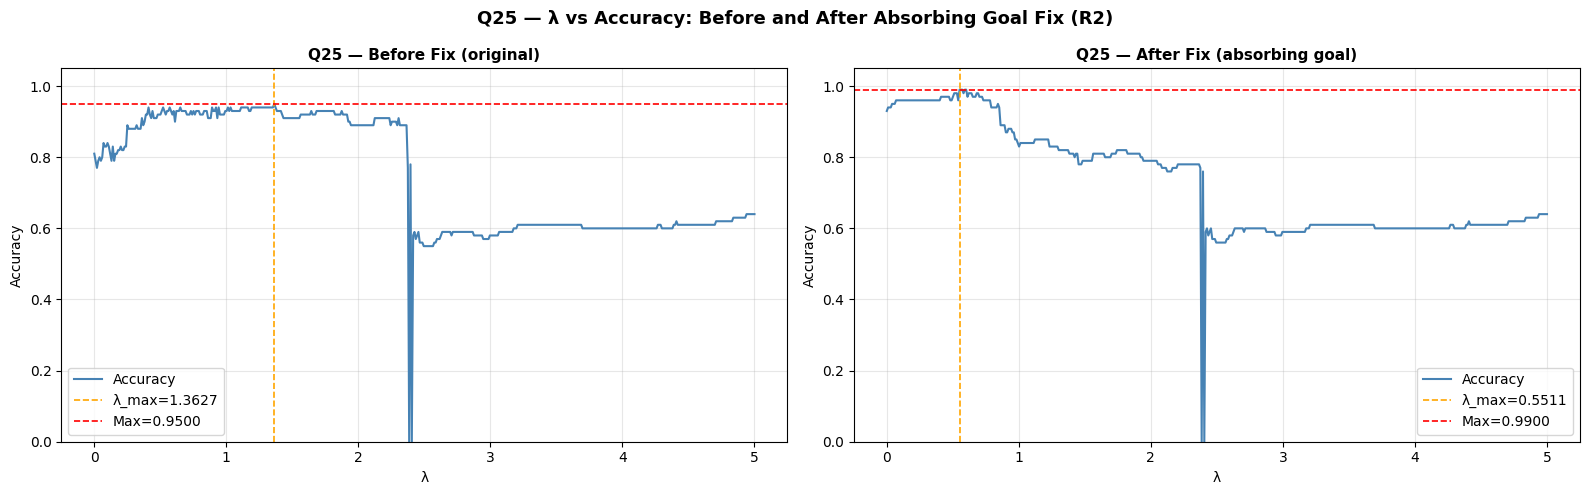

  └─ Saved: Q25_reward_heatmap_after_fix.png


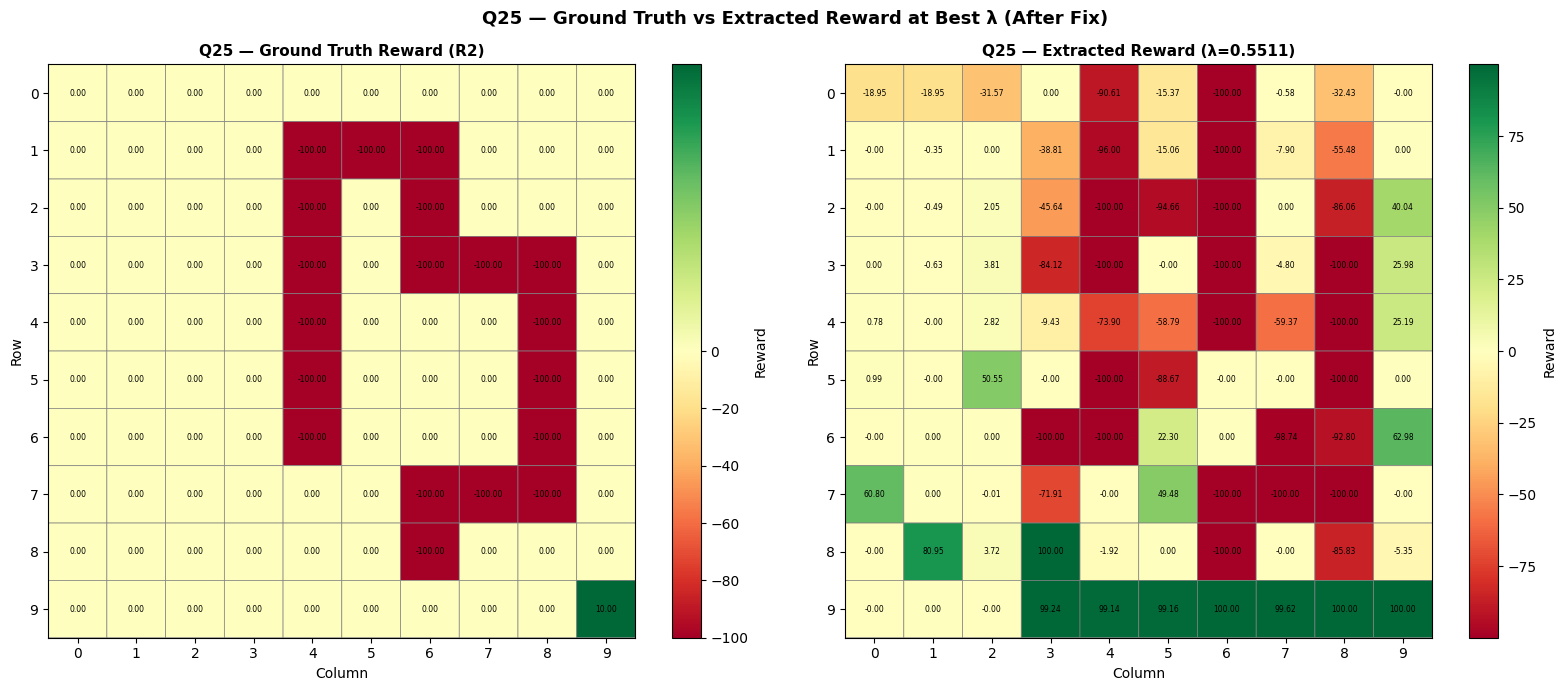

  └─ Saved: Q25_value_heatmap_after_fix.png


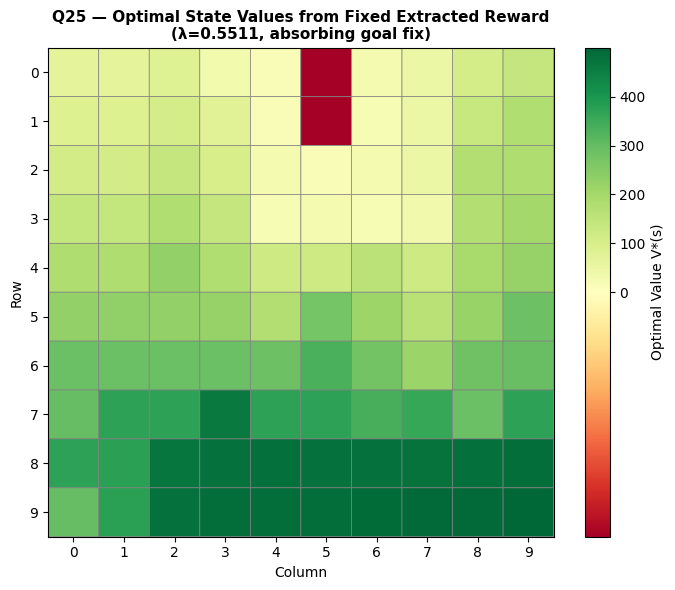

  └─ Saved: Q25_policy_three_way.png


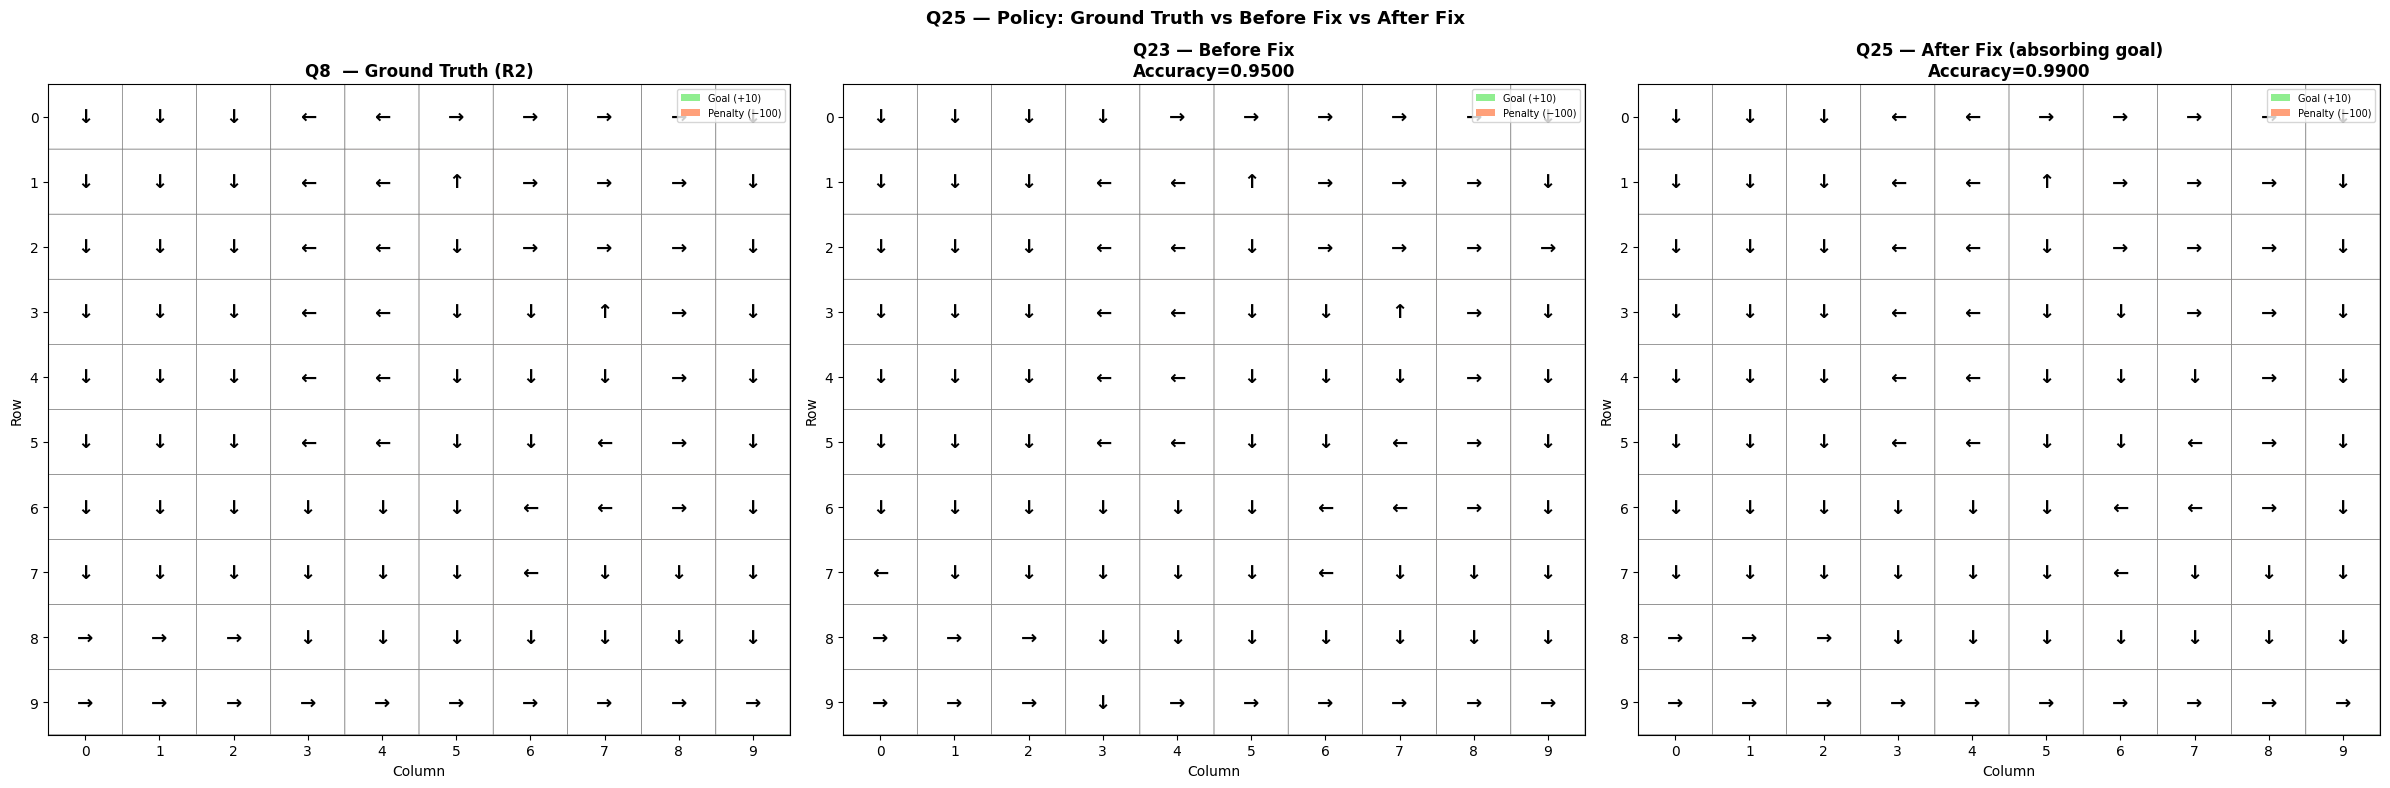


=== Q25 Summary ===
Accuracy before fix : 0.9500
Accuracy after  fix : 0.9900
Change in accuracy  : +0.0400


In [19]:
# ══════════════════════════════════════════════════════════
#  QUESTION 25
# ══════════════════════════════════════════════════════════
import matplotlib.patches as mpatches

GOAL_STATE = 99

# ── Fixed value iteration (absorbing goal) ──────────────────
def value_iteration_absorbing(P, R, goal_state=GOAL_STATE,
                               gamma=GAMMA, epsilon=EPSILON):
    """
    Modified value iteration: goal state is absorbing.
    V(goal) = R(goal) / (1 - γ) enforced after every Bellman update.
    """
    n = P.shape[1]
    V = np.zeros(n)
    V[goal_state] = R[goal_state] / (1 - gamma)
    while True:
        target = R + gamma * V
        Q      = P @ target
        V_new  = Q.max(axis=0)
        V_new[goal_state] = R[goal_state] / (1 - gamma)
        delta  = np.abs(V_new - V).max()
        V      = V_new
        if delta < epsilon:
            break
    return V

# ── Figure 1
#    Q8 vs Q23 side by side, discrepancies marked with circles
# ───────────────────────────────────────────────────────────
diff_states = np.where(policy2_extracted != policy2)[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_policy_grid_r2(policy2,           R2, 'Q8  — Ground Truth Policy (R2)', axes[0])
plot_policy_grid_r2(policy2_extracted, R2, 'Q23 — Extracted Policy (R2)',    axes[1])

ax = axes[1]
for s in diff_states:
    row, col = state_to_rc(s)
    next_s   = deterministic_move(s, policy2_extracted[s])
    is_stuck = (next_s == s)
    color    = 'red' if is_stuck else 'blue'
    ax.add_patch(plt.Circle((col + 0.5, row + 0.5), 0.42,
                             color=color, fill=False, linewidth=2.5, zorder=5))

red_patch  = mpatches.Patch(edgecolor='red',  facecolor='none', linewidth=2,
                             label='Discrepancy 1: stuck/off-grid (fixable)')
blue_patch = mpatches.Patch(edgecolor='blue', facecolor='none', linewidth=2,
                             label='Discrepancy 2: wrong direction (hard to fix)')
axes[1].legend(handles=[red_patch, blue_patch], loc='upper center',
               fontsize=7, framealpha=0.9)

plt.suptitle('Q25 — Two Major Discrepancies in Extracted Policy vs Ground Truth',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('Q25_discrepancy_marked.png')
plt.show()

# ── Figure 2
#    λ vs accuracy before and after fix (side by side)
# ───────────────────────────────────────────────────────────
print("Re-sweeping λ with absorbing goal fix ...")
accuracies_2_fix = np.zeros(500)

for i, lam in enumerate(tqdm(lambda_values, desc='Q25 λ sweep (fixed)')):
    R_ext = solve_irl_lp(G_cv2, h_cv2, lam)
    if R_ext is None:
        accuracies_2_fix[i] = 0.0
        continue
    V_ext          = value_iteration_absorbing(P_CHOSEN, R_ext)
    policy_agent,_ = compute_policy(P_CHOSEN, R_ext, V_ext)
    accuracies_2_fix[i] = compute_accuracy(policy_agent, policy2)

best_idx_fix = accuracies_2_fix.argmax()
lam2_fix_max = lambda_values[best_idx_fix]
acc2_fix_max = accuracies_2_fix[best_idx_fix]

print(f"Before fix — max accuracy: {acc2_max:.4f}  at λ={lam2_max:.4f}")
print(f"After  fix — max accuracy: {acc2_fix_max:.4f}  at λ={lam2_fix_max:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, accs, lm, am, label in zip(
    axes,
    [accuracies_2, accuracies_2_fix],
    [lam2_max, lam2_fix_max],
    [acc2_max,  acc2_fix_max],
    ['Before Fix (original)', 'After Fix (absorbing goal)']
):
    ax.plot(lambda_values, accs, color='steelblue', linewidth=1.5, label='Accuracy')
    ax.axvline(lm, color='orange', linestyle='--', linewidth=1.2, label=f'λ_max={lm:.4f}')
    ax.axhline(am, color='red',    linestyle='--', linewidth=1.2, label=f'Max={am:.4f}')
    ax.set_title(f'Q25 — {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('λ'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Q25 — λ vs Accuracy: Before and After Absorbing Goal Fix (R2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('Q25_accuracy_before_after_fix.png')
plt.show()

# ── Figure 3
#    Heatmap of extracted reward at lam2_fix_max
# ───────────────────────────────────────────────────────────
R2_ext_fix     = solve_irl_lp(G_cv2, h_cv2, lam2_fix_max)
V2_ext_fix     = value_iteration_absorbing(P_CHOSEN, R2_ext_fix)
policy2_fix, _ = compute_policy(P_CHOSEN, R2_ext_fix, V2_ext_fix)
acc_fix_final  = compute_accuracy(policy2_fix, policy2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_reward_heatmap_irl(R2,         'Q25 — Ground Truth Reward (R2)',               axes[0])
plot_reward_heatmap_irl(R2_ext_fix, f'Q25 — Extracted Reward (λ={lam2_fix_max:.4f})', axes[1])
plt.suptitle('Q25 — Ground Truth vs Extracted Reward at Best λ (After Fix)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('Q25_reward_heatmap_after_fix.png')
plt.show()

# ── Figure 4
#    Optimal state values from fixed extracted reward
# ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
grid_fix   = value_to_grid(V2_ext_fix)
vmin, vmax = V2_ext_fix.min(), V2_ext_fix.max()
vcenter    = 0.0 if vmin < 0 < vmax else (vmin + vmax) / 2
norm       = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter,
                                   vmax=max(vmax, vcenter + 1e-9))
pcm = ax.pcolor(grid_fix, cmap='RdYlGn', norm=norm,
                edgecolors='grey', linewidths=0.5)
plt.colorbar(pcm, ax=ax, label='Optimal Value V*(s)')
ax.set_title(f'Q25 — Optimal State Values from Fixed Extracted Reward\n'
             f'(λ={lam2_fix_max:.4f}, absorbing goal fix)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.set_xticks(np.arange(10)+0.5); ax.set_xticklabels(range(10))
ax.set_yticks(np.arange(10)+0.5); ax.set_yticklabels(range(10))
ax.invert_yaxis()
plt.tight_layout()
savefig('Q25_value_heatmap_after_fix.png')
plt.show()

# ── Figure 5
#    Three-way policy comparison: GT / Before Fix / After Fix
# ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
plot_policy_grid_r2(policy2,           R2,
                    'Q8  — Ground Truth (R2)',              axes[0])
plot_policy_grid_r2(policy2_extracted, R2,
                    f'Q23 — Before Fix\nAccuracy={acc_q23:.4f}', axes[1])
plot_policy_grid_r2(policy2_fix,       R2,
                    f'Q25 — After Fix (absorbing goal)\nAccuracy={acc_fix_final:.4f}', axes[2])
plt.suptitle('Q25 — Policy: Ground Truth vs Before Fix vs After Fix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('Q25_policy_three_way.png')
plt.show()

print(f"\n=== Q25 Summary ===")
print(f"Accuracy before fix : {acc_q23:.4f}")
print(f"Accuracy after  fix : {acc_fix_final:.4f}")
print(f"Change in accuracy  : {acc_fix_final - acc_q23:+.4f}")